# 🚗 Used Car Price Prediction – Project Overview

## 📌 Objective

The aim of this project is to develop a regression model that accurately predicts the **selling price** of used cars based on various car attributes, such as brand, age, mileage, fuel type, and physical condition.

This machine learning project follows a **classic ML workflow** using `scikit-learn` without pipelines, making each step manually visible and explainable.

---

## 📊 Dataset Overview

- **Total Features**: 13 (excluding target)
- **Target Variable**: `price` (Selling price in £)
- **Size**: ~79,000 rows (from the notebook)
- **Feature Description**:

| Feature           | Description |
|-------------------|-------------|
| `carID`           | Unique identifier for each car (to be dropped) |
| `Brand`           | Car's brand (e.g. Ford, Toyota) |
| `model`           | Car model name |
| `year`            | Year of registration |
| `mileage`         | Total distance driven (in miles) |
| `tax`             | Annual tax cost in £ (2020) |
| `fuelType`        | Type of fuel (Diesel, Petrol, Hybrid, Electric) |
| `mpg`             | Miles per gallon |
| `engineSize`      | Engine capacity in liters |
| `paintQuality%`   | Mechanic-assessed paint & hull condition (%) |
| `previousOwners`  | Number of previous owners |
| `hasDamage`       | Indicates if the car is damaged (Boolean) |

---

## ⚙️ Project Workflow

1. **Data Exploration**
   - Inspected dataset structure, types, and missing values
   - Visualized the target distribution (`price`) and key features

2. **Preprocessing**
   - Dropped `carID` as it’s non-informative
   - Handled missing values:
     - **Numerical**: Median imputation
     - **Categorical**: Most frequent imputation
   - Scaled numerical features using `StandardScaler`
   - One-hot encoded categorical features (e.g., `Brand`, `fuelType`)
   - Converted `hasDamage` to binary if not already

3. **Modeling**
   - Chose **Linear Regression** as a baseline model
   - Trained model using `train_test_split` (80/20)

4. **Evaluation**
   - Calculated:
     - **Root Mean Squared Error (RMSE)**
     - **R² score**
   - Visualized actual vs predicted prices using a regression plot

---

## 🛠️ Tools Used

- Python 3
- pandas, numpy
- matplotlib, seaborn
- scikit-learn (for modeling and preprocessing)

---

## ✅ Output

- Trained regression model on preprocessed features
- Model performance metrics (RMSE, R²)
- Visual insights into prediction quality
- Ready to scale up using more advanced regressors or tuning techniques





## 🧩 Problem Statement

**Cars 4 You**, a car resale company, is experiencing significant delays in vehicle evaluations, which negatively affects customer satisfaction and market competitiveness. Currently, the valuation process requires a physical inspection by a mechanic, creating a bottleneck.

The company seeks to develop a **machine learning model** that can predict the **resale price of used cars** based solely on information provided online by users. This would allow users to receive instant and reasonably accurate price estimates without visiting the dealership.

The project aims to deliver a solution that:
- Predicts the `price` of a used car based on structured input features (e.g., brand, year, mileage, engine size)
- Does **not rely on** the mechanic-evaluated `price` during prediction (it's the target, not an input)
- Can be deployed to support customer interaction and scale to unseen listings

The final model will be evaluated based on its predictive accuracy (e.g., RMSE, R²) and its ability to generalize to unseen test data, as verified through a Kaggle submission.



# Car Price Prediction Project - Starter Notebook

In [33]:
!pip install ydata-profiling

In [34]:
!pip install tensorflow

# SECTION 1: LIBRARY IMPORTS

In [1]:
# -----------------------------------
# 📚 Import Required Libraries
# -----------------------------------
import pandas as pd              # For data manipulation
import numpy as np               # For numerical operations
import matplotlib.pyplot as plt  # For plotting
import seaborn as sns            # For visualizations

from sklearn.model_selection import train_test_split  # For splitting data
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer              # For handling missing values
from sklearn.linear_model import LinearRegression     # For baseline model
from sklearn.metrics import mean_squared_error, r2_score  # For evaluation


# SECTION 2 – LOAD AND EXPLORE DATA

### 2.1 Dataset Overview
### 🔹 Tasks
- Load the CSV file
- View the first few rows (`df.head()`)
- Check column types and null counts (`df.info()`)
- Get summary statistics for numeric features (`df.describe()`)
- Count number of rows and columns (`df.shape`)

In [2]:
# -----------------------------------
# 📥 Load the Dataset
# -----------------------------------
df = pd.read_csv('train.csv')  # Replace with correct path if needed

# Basic info
print("Shape:", df.shape)
print("\nData Types & Missing Values:")
print(df.info())

# Show first few rows
df.head()


Shape: (75973, 14)

Data Types & Missing Values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75973 entries, 0 to 75972
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   carID           75973 non-null  int64  
 1   Brand           74452 non-null  object 
 2   model           74456 non-null  object 
 3   year            74482 non-null  float64
 4   price           75973 non-null  int64  
 5   transmission    74451 non-null  object 
 6   mileage         74510 non-null  float64
 7   fuelType        74462 non-null  object 
 8   tax             68069 non-null  float64
 9   mpg             68047 non-null  float64
 10  engineSize      74457 non-null  float64
 11  paintQuality%   74449 non-null  float64
 12  previousOwners  74423 non-null  float64
 13  hasDamage       74425 non-null  float64
dtypes: float64(8), int64(2), object(4)
memory usage: 8.1+ MB
None


,carID,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
0,69512,VW,Golf,2016.0,22290,Semi-Auto,28421.0,Petrol,NaN,11.417268,2.0,63.0,4.000000,0.0
1,53000,Toyota,Yaris,2019.0,13790,Manual,4589.0,Petrol,145.0,47.900000,1.5,50.0,1.000000,0.0
2,6366,Audi,Q2,2019.0,24990,Semi-Auto,3624.0,Petrol,145.0,40.900000,1.5,56.0,4.000000,0.0
3,29021,Ford,FIESTA,2018.0,12500,anual,9102.0,Petrol,145.0,65.700000,1.0,50.0,-2.340306,0.0
4,10062,BMW,2 Series,2019.0,22995,Manual,1000.0,Petrol,145.0,42.800000,1.5,97.0,3.000000,0.0


In [36]:

df = pd.read_csv('train.csv')

# Display basic info to confirm successful loading
print("✅ Dataset Loaded Successfully")
print(f"Shape: {df.shape}")
df.head()

✅ Dataset Loaded Successfully
Shape: (75973, 14)


,carID,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
0,69512,VW,Golf,2016.0,22290,Semi-Auto,28421.0,Petrol,NaN,11.417268,2.0,63.0,4.000000,0.0
1,53000,Toyota,Yaris,2019.0,13790,Manual,4589.0,Petrol,145.0,47.900000,1.5,50.0,1.000000,0.0
2,6366,Audi,Q2,2019.0,24990,Semi-Auto,3624.0,Petrol,145.0,40.900000,1.5,56.0,4.000000,0.0
3,29021,Ford,FIESTA,2018.0,12500,anual,9102.0,Petrol,145.0,65.700000,1.0,50.0,-2.340306,0.0
4,10062,BMW,2 Series,2019.0,22995,Manual,1000.0,Petrol,145.0,42.800000,1.5,97.0,3.000000,0.0


In [4]:
# -----------------------------------
# 📊 Basic Data Exploration
# -----------------------------------

# Statistical summary of numeric features
df.describe()




,carID,year,price,mileage,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
count,75973.000000,74482.000000,75973.000000,74510.000000,68069.000000,68047.000000,74457.000000,74449.000000,74423.000000,74425.0
mean,37986.000000,2017.096611,16881.889553,23004.184088,120.329078,55.152666,1.660136,64.590667,1.994580,0.0
std,21931.660338,2.208704,9736.926322,22129.788366,65.521176,16.497837,0.573462,21.021065,1.472981,0.0
min,0.000000,1970.000000,450.000000,-58540.574478,-91.121630,-43.421768,-0.103493,1.638913,-2.345650,0.0
25%,18993.000000,2016.000000,10200.000000,7423.250000,125.000000,46.300000,1.200000,47.000000,1.000000,0.0
50%,37986.000000,2017.000000,14699.000000,17300.000000,145.000000,54.300000,1.600000,65.000000,2.000000,0.0
75%,56979.000000,2019.000000,20950.000000,32427.500000,145.000000,62.800000,2.000000,82.000000,3.000000,0.0
max,75972.000000,2024.121759,159999.000000,323000.000000,580.000000,470.800000,6.600000,125.594308,6.258371,0.0


In [5]:
# Count missing values
missing = df.isnull().sum()
print("\nMissing Values:")
print(missing[missing > 0])




Missing Values:
Brand             1521
model             1517
year              1491
transmission      1522
mileage           1463
fuelType          1511
tax               7904
mpg               7926
engineSize        1516
paintQuality%     1524
previousOwners    1550
hasDamage         1548
dtype: int64


In [6]:
# Data types by category
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()



In [7]:
print("\nNumeric Columns:", num_cols)
print("Categorical Columns:", cat_cols)


Numeric Columns: ['carID', 'year', 'price', 'mileage', 'tax', 'mpg', 'engineSize', 'paintQuality%', 'previousOwners', 'hasDamage']
Categorical Columns: ['Brand', 'model', 'transmission', 'fuelType']


In [37]:
# Separate categorical and numerical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df.select_dtypes(exclude=['object']).columns.tolist()

# Ensure 'carID' is at the front and only appears once
if 'carID' in df.columns:
    if 'carID' in numerical_cols:
        numerical_cols.remove('carID')
    if 'carID' not in categorical_cols:
        categorical_cols = ['carID'] + categorical_cols

# Combine and ensure no duplicates
ordered_columns = categorical_cols + numerical_cols
ordered_columns = list(dict.fromkeys(ordered_columns))  # Removes duplicates while preserving order

# Reorder the DataFrame
df_reordered = df[ordered_columns]

# Show the new column order
df_reordered.head()



,carID,Brand,model,transmission,fuelType,year,price,mileage,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
0,69512,VW,Golf,Semi-Auto,Petrol,2016.0,22290,28421.0,NaN,11.417268,2.0,63.0,4.000000,0.0
1,53000,Toyota,Yaris,Manual,Petrol,2019.0,13790,4589.0,145.0,47.900000,1.5,50.0,1.000000,0.0
2,6366,Audi,Q2,Semi-Auto,Petrol,2019.0,24990,3624.0,145.0,40.900000,1.5,56.0,4.000000,0.0
3,29021,Ford,FIESTA,anual,Petrol,2018.0,12500,9102.0,145.0,65.700000,1.0,50.0,-2.340306,0.0
4,10062,BMW,2 Series,Manual,Petrol,2019.0,22995,1000.0,145.0,42.800000,1.5,97.0,3.000000,0.0


In [38]:
df=df_reordered

In [39]:
# Count and sort missing values
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

# Create a DataFrame with counts and percentages
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing Percentage': (missing / len(df)) * 100
})

# Display the result
print("🔍 Missing Values with Percentage:\n")
print(missing_df)



🔍 Missing Values with Percentage:

                Missing Count  Missing Percentage
mpg                      7926           10.432654
tax                      7904           10.403696
previousOwners           1550            2.040198
hasDamage                1548            2.037566
paintQuality%            1524            2.005976
transmission             1522            2.003343
Brand                    1521            2.002027
model                    1517            1.996762
engineSize               1516            1.995446
fuelType                 1511            1.988864
year                     1491            1.962539
mileage                  1463            1.925684


In [40]:
# Exibir resumo completo das colunas
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75973 entries, 0 to 75972
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   carID           75973 non-null  int64  
 1   Brand           74452 non-null  object 
 2   model           74456 non-null  object 
 3   transmission    74451 non-null  object 
 4   fuelType        74462 non-null  object 
 5   year            74482 non-null  float64
 6   price           75973 non-null  int64  
 7   mileage         74510 non-null  float64
 8   tax             68069 non-null  float64
 9   mpg             68047 non-null  float64
 10  engineSize      74457 non-null  float64
 11  paintQuality%   74449 non-null  float64
 12  previousOwners  74423 non-null  float64
 13  hasDamage       74425 non-null  float64
dtypes: float64(8), int64(2), object(4)
memory usage: 8.1+ MB


In [41]:
# Display summary statistics for numerical features
print("📊 Summary Statistics for Numeric Features:\n")
df.describe().T


📊 Summary Statistics for Numeric Features:



,count,mean,std,min,25%,50%,75%,max
carID,75973.0,37986.000000,21931.660338,0.000000,18993.00,37986.0,56979.0,75972.000000
year,74482.0,2017.096611,2.208704,1970.000000,2016.00,2017.0,2019.0,2024.121759
price,75973.0,16881.889553,9736.926322,450.000000,10200.00,14699.0,20950.0,159999.000000
mileage,74510.0,23004.184088,22129.788366,-58540.574478,7423.25,17300.0,32427.5,323000.000000
tax,68069.0,120.329078,65.521176,-91.121630,125.00,145.0,145.0,580.000000
mpg,68047.0,55.152666,16.497837,-43.421768,46.30,54.3,62.8,470.800000
engineSize,74457.0,1.660136,0.573462,-0.103493,1.20,1.6,2.0,6.600000
paintQuality%,74449.0,64.590667,21.021065,1.638913,47.00,65.0,82.0,125.594308
previousOwners,74423.0,1.994580,1.472981,-2.345650,1.00,2.0,3.0,6.258371
hasDamage,74425.0,0.000000,0.000000,0.000000,0.00,0.0,0.0,0.000000


In [42]:
# Summary statistics for categorical (object) columns
categorical_summary = df.describe(include='object').T
print("📋 Categorical Feature Summary:\n")
categorical_summary


📋 Categorical Feature Summary:



,count,unique,top,freq
Brand,74452,72,Ford,14808
model,74456,735,Focus,6353
transmission,74451,40,Manual,38050
fuelType,74462,34,Petrol,37995


In [43]:
# Get the number of rows and columns
rows, columns = df.shape
print(f"📐 Dataset contains {rows} rows and {columns} columns.")


📐 Dataset contains 75973 rows and 14 columns.


### 2.2 Data Consistency Checks

### 🔹 Tasks
- Identify and visualize missing values (`df.isnull().sum()`, `missingno`)
- Check for duplicate rows (`df.duplicated().sum()`)
- Ensure consistency in date/year formats
- Standardize categorical values (e.g., brands, models, fuel type, casing)

In [44]:
pip install missingno


Note: you may need to restart the kernel to use updated packages.


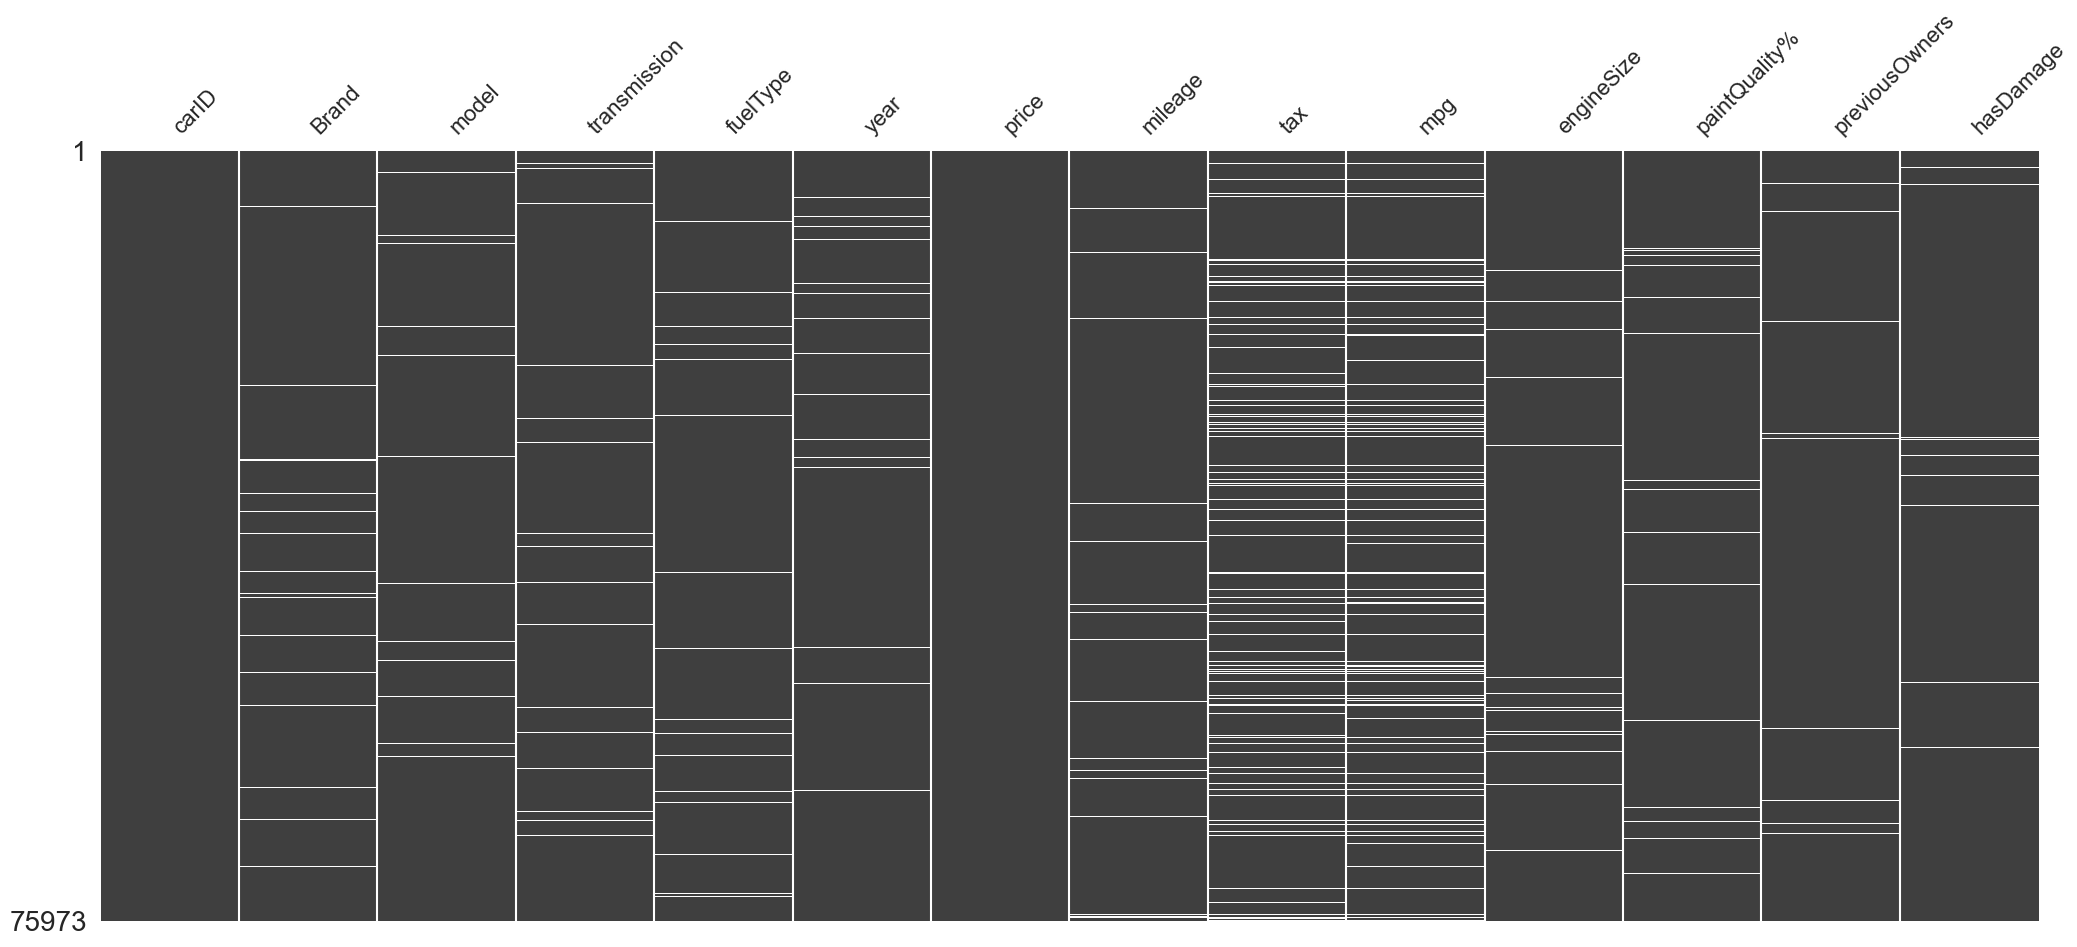

In [45]:
import missingno as msno
import matplotlib.pyplot as plt

# Plot missing values matrix without the sparkline
msno.matrix(df, sparkline=False)
plt.show()



In [46]:
# Count total number of duplicate rows
duplicate_count = df.duplicated().sum()
print(f"🔁 Number of duplicate rows: {duplicate_count}")


🔁 Number of duplicate rows: 0


In [47]:
# 🔹 Brand — Original Overview
print(f"\n🔹 Brand — {df['Brand'].nunique()} unique values")
print(df['Brand'].value_counts(dropna=False))

# Step 1: Lowercase and strip whitespaces
df['Brand'] = df['Brand'].str.lower().str.strip()

# Step 2: Define corrections for common typos
brand_corrections = {
    # Ford
    'for': 'ford', 'ord': 'ford', 'or': 'ford',

    # Mercedes
    'mercede': 'mercedes', 'ercedes': 'mercedes', 'ercede': 'mercedes',

    # Volkswagen
    'v': 'volkswagen', 'w': 'volkswagen', 'vw': 'volkswagen',

    # Opel
    'ope': 'opel', 'pel': 'opel', 'pe': 'opel',

    # BMW
    'mw': 'bmw', 'bm': 'bmw',

    # Audi
    'aud': 'audi', 'udi': 'audi',

    # Skoda
    'skod': 'skoda', 'koda': 'skoda', 'kod': 'skoda',

    # Hyundai
    'hyunda': 'hyundai', 'yundai': 'hyundai', 'yunda': 'hyundai', 'ud': 'hyundai',

    # Toyota
    'toyot': 'toyota', 'oyota': 'toyota',
}

# Step 3: Apply typo corrections
df['Brand'] = df['Brand'].replace(brand_corrections)

# Step 4: Replace actual missing values with 'unknown'
df['Brand'] = df['Brand'].fillna('unknown')

# 🔹 Brand — Cleaned Overview
print(f"\n🔹 Brand (cleaned) — {df['Brand'].nunique()} unique values")
print(df['Brand'].value_counts(dropna=False))




🔹 Brand — 72 unique values
Brand
Ford        14808
Mercedes    10754
VW           9780
Opel         8645
BMW          6968
            ...  
OYOTA           2
SKOD            1
TOYOT           1
skod            1
toyot           1
Name: count, Length: 73, dtype: int64

🔹 Brand (cleaned) — 10 unique values
Brand
ford          16063
mercedes      11674
volkswagen    10385
opel           9352
bmw            7392
audi           7322
toyota         4622
skoda          4303
hyundai        3339
unknown        1521
Name: count, dtype: int64



🔹 Brand — 10 unique values (raw)
Brand
ford          16063
mercedes      11674
volkswagen    10385
opel           9352
bmw            7392
audi           7322
toyota         4622
skoda          4303
hyundai        3339
unknown        1521
Name: count, dtype: int64

🔹 Brand (cleaned) — 10 unique values
        brand  count
0        ford  16063
1    mercedes  11674
2  volkswagen  10385
3        opel   9352
4         bmw   7392
5        audi   7322
6      toyota   4622
7       skoda   4303
8     hyundai   3339
9     unknown   1521


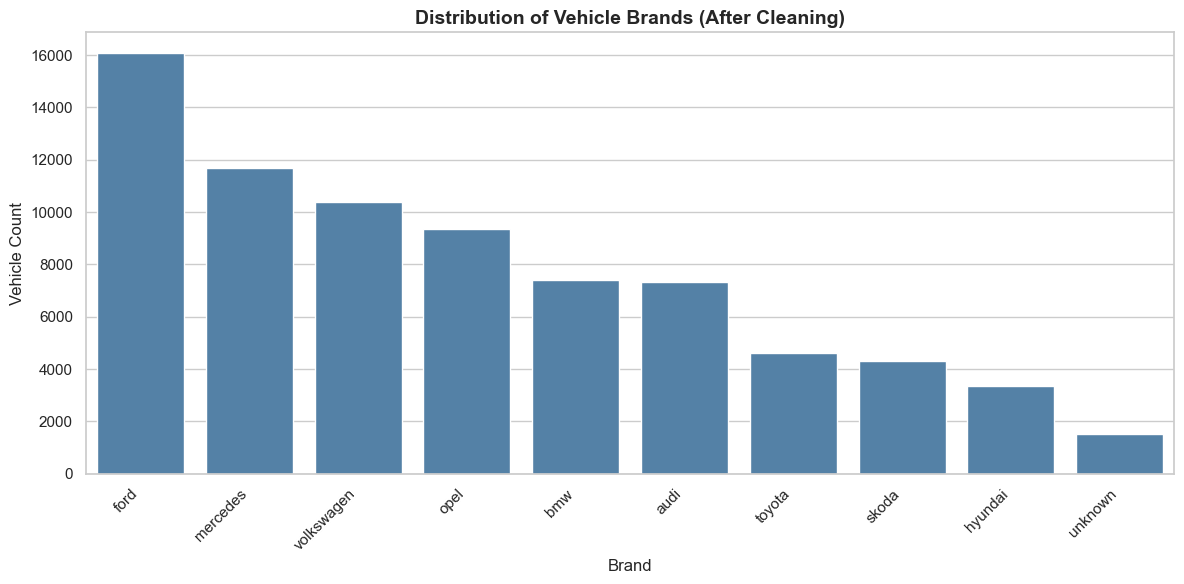

In [48]:
# -----------------------------------------------------
# 🧼 Brand Cleaning + Distribution Visualization
# -----------------------------------------------------
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Step 1: Original Overview ---
print(f"\n🔹 Brand — {df['Brand'].nunique()} unique values (raw)")
print(df['Brand'].value_counts(dropna=False))

# --- Step 2: Normalize brand names ---
df['Brand'] = df['Brand'].astype(str).str.lower().str.strip()

# --- Step 3: Define corrections for common typos ---
brand_corrections = {
    # Ford
    'for': 'ford', 'ord': 'ford', 'or': 'ford',

    # Mercedes
    'mercede': 'mercedes', 'ercedes': 'mercedes', 'ercede': 'mercedes',

    # Volkswagen
    'v': 'volkswagen', 'w': 'volkswagen', 'vw': 'volkswagen',

    # Opel
    'ope': 'opel', 'pel': 'opel', 'pe': 'opel',

    # BMW
    'mw': 'bmw', 'bm': 'bmw',

    # Audi
    'aud': 'audi', 'udi': 'audi',

    # Skoda
    'skod': 'skoda', 'koda': 'skoda', 'kod': 'skoda',

    # Hyundai
    'hyunda': 'hyundai', 'yundai': 'hyundai', 'yunda': 'hyundai', 'ud': 'hyundai',

    # Toyota
    'toyot': 'toyota', 'oyota': 'toyota',
}

# --- Step 4: Apply typo corrections ---
df['Brand'] = df['Brand'].replace(brand_corrections)

# --- Step 5: Replace missing or invalid entries ---
df['Brand'] = df['Brand'].replace(['', 'nan', 'none', '<na>'], pd.NA).fillna('unknown')

# --- Step 6: Cleaned Overview ---
brand_counts = df['Brand'].value_counts(dropna=False).reset_index()
brand_counts.columns = ['brand', 'count']

print(f"\n🔹 Brand (cleaned) — {df['Brand'].nunique()} unique values")
print(brand_counts)

# --- Step 7: Visualization — Brand Distribution ---
plt.figure(figsize=(12, 6))
sns.barplot(x='brand', y='count', data=brand_counts, color='steelblue')

plt.title("Distribution of Vehicle Brands (After Cleaning)", fontsize=14, fontweight='bold')
plt.xlabel("Brand", fontsize=12)
plt.ylabel("Vehicle Count", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [50]:
# -----------------------------------------------------
# 🔧 Step: Clean model names and infer missing brands (multi-brand inference)
# -----------------------------------------------------
import pandas as pd

# --- Step 1: Create grouped DataFrame (if not already done) ---
if 'brand_model_counts' not in locals():
    brand_model_counts = (
        df.groupby(['Brand', 'model'])
          .size()
          .reset_index(name='vehicle_count')
    )

# --- Step 2: Fix truncated or inconsistent model names ---
model_corrections = {
    # ✅ Audi
    't': 'tt',

    # ✅ Ford
    'b-ma': 'b-max', 'c-ma': 'c-max', 's-ma': 's-max', 'edg': 'edge', 'kug': 'kuga', 'focu': 'focus',

    # ✅ Hyundai
    'i1': 'i10', 'i2': 'i20', 'i3': 'i30', 'i80': 'i800', 'ioni': 'ioniq', 'ix2': 'ix20',
    'kon': 'kona', 'veloste': 'veloster',

    # ✅ Mercedes
    'a clas': 'a-class', 'b class': 'b-class', 'c clas': 'c-class', 'c class': 'c-class',
    'cl class': 'cl-class', 'cls clas': 'cls-class', 'e class': 'e-class',
    'g class': 'g-class', 'gla class': 'gla-class', 'glb-class': 'glb-class',
    'glc class': 'glc-class', 'gle class': 'gle-class', 'gls class': 'gls-class',
    'm class': 'm-class', 's class': 's-class', 'sl clas': 'sl-class', 'v class': 'v-class',

    # ✅ Opel
    'astr': 'astra', 'agila': 'agila', 'adam': 'adam', 'gtc': 'gtc', 'viva': 'viva',

    # ✅ Skoda
    'karo': 'karoq', 'scal': 'scala',

    # ✅ Toyota
    'yari': 'yaris',

    # ✅ Volkswagen
    'gol': 'golf', 'pol': 'polo',
}

brand_model_counts['model'] = brand_model_counts['model'].replace(model_corrections)

# --- Step 3: Infer brand for 'unknown' models ---
model_to_brand = {
    # ✅ BMW
    'i8': 'bmw', 'x': 'bmw',

    # ✅ Audi
    'a': 'audi', 'q': 'audi', 'tt': 'audi',

    # ✅ Mercedes
    'a-class': 'mercedes', 'b-class': 'mercedes', 'c-class': 'mercedes',
    'cl-class': 'mercedes', 'cls-class': 'mercedes', 'e-class': 'mercedes',
    'g-class': 'mercedes', 'gla-class': 'mercedes', 'glb-class': 'mercedes',
    'glc-class': 'mercedes', 'gle-class': 'mercedes', 'gls-class': 'mercedes',
    'm-class': 'mercedes', 's-class': 'mercedes', 'sl-class': 'mercedes', 'v-class': 'mercedes',

    # ✅ Ford
    'edge': 'ford', 'galaxy': 'ford', 'grand c-max': 'ford', 'mustang': 'ford',

    # ✅ Opel
    'adam': 'opel', 'agila': 'opel', 'astra': 'opel', 'gtc': 'opel', 'viva': 'opel',

    # ✅ Skoda
    'karoq': 'skoda', 'rapid': 'skoda', 'scala': 'skoda',

    # ✅ Toyota
    'yaris': 'toyota',

    # ✅ Volkswagen
    'cc': 'volkswagen', 'golf': 'volkswagen', 'golf sv': 'volkswagen',
    'polo': 'volkswagen', 'shuttle': 'volkswagen', 'tiguan allspace': 'volkswagen',

    # ✅ Hyundai
    'i40': 'hyundai', 'i800': 'hyundai', 'ix35': 'hyundai',
}

mask_unknown = brand_model_counts['Brand'].str.lower() == 'unknown'
brand_model_counts.loc[mask_unknown, 'Brand'] = (
    brand_model_counts.loc[mask_unknown, 'model']
    .map(model_to_brand)
    .fillna(brand_model_counts.loc[mask_unknown, 'Brand'])
)

# --- Step 4: Merge duplicates ---
brand_model_counts = (
    brand_model_counts
    .groupby(['Brand', 'model'], as_index=False)['vehicle_count']
    .sum()
)

# --- Step 5: Sort alphabetically ---
brand_model_counts = brand_model_counts.sort_values(by=['Brand', 'model']).reset_index(drop=True)

# --- Step 6: Check remaining unknowns ---
remaining_unknowns = brand_model_counts['Brand'].str.lower().eq('unknown').sum()
print(f"\n❓ Remaining 'unknown' brands after inference: {remaining_unknowns}\n")

# --- Step 7: Display cleaned results ---
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print("\n📊 Cleaned, Sorted, and Merged Brand-Model Counts:\n")
    print(brand_model_counts[['Brand', 'model', 'vehicle_count']])

# --- Step 8: Save cleaned dataset ---
brand_model_counts.to_csv('cleaned_brand_model_counts_final.csv', index=False)
print("\n💾 Saved fully cleaned dataset to 'cleaned_brand_model_counts_final.csv'")













    



❓ Remaining 'unknown' brands after inference: 93


📊 Cleaned, Sorted, and Merged Brand-Model Counts:

          Brand                  model  vehicle_count
0          audi                      a             96
1          audi                     a1            905
2          audi                     a2              1
3          audi                     a3           1263
4          audi                     a4            911
5          audi                     a5            573
6          audi                     a6            475
7          audi                     a7             82
8          audi                     a8             77
9          audi                      q             49
10         audi                     q2            532
11         audi                     q3            955
12         audi                     q5            576
13         audi                     q7            265
14         audi                     q8             43
15         audi                  

In [54]:
# -----------------------------------------------------
# 🔧 Step: Clean model names and infer missing brands (Enhanced Multi-Brand Inference)
# -----------------------------------------------------
import pandas as pd

# --- Step 1: Create grouped DataFrame (if not already done) ---
if 'brand_model_counts' not in locals():
    brand_model_counts = (
        df.groupby(['Brand', 'model'])
          .size()
          .reset_index(name='vehicle_count')
    )

# --- Step 2: Fix truncated or inconsistent model names ---
model_corrections = {
    # ✅ Audi
    't': 'tt',

    # ✅ Ford
    'b-ma': 'b-max', 'c-ma': 'c-max', 's-ma': 's-max', 'edg': 'edge', 
    'kug': 'kuga', 'focu': 'focus', 'mondea': 'mondeo',

    # ✅ Hyundai
    'i1': 'i10', 'i2': 'i20', 'i3': 'i30', 'i80': 'i800', 
    'ioni': 'ioniq', 'ix2': 'ix20', 'kon': 'kona', 'veloste': 'veloster',

    # ✅ Mercedes
    'a clas': 'a-class', 'b class': 'b-class', 'c clas': 'c-class', 'c class': 'c-class',
    'cl class': 'cl-class', 'cls clas': 'cls-class', 'e class': 'e-class',
    'g class': 'g-class', 'gla class': 'gla-class', 'glb-class': 'glb-class',
    'glc class': 'glc-class', 'gle class': 'gle-class', 'gls class': 'gls-class',
    'm class': 'm-class', 's class': 's-class', 'sl clas': 'sl-class', 'v class': 'v-class',

    # ✅ Opel
    'astr': 'astra', 'agil': 'agila', 'adam': 'adam', 'gtc': 'gtc', 'viva': 'viva',

    # ✅ Skoda
    'karo': 'karoq', 'scal': 'scala', 'yeti outdoo': 'yeti outdoor',

    # ✅ Toyota
    'yari': 'yaris', 'rav': 'rav4',

    # ✅ Volkswagen
    'gol': 'golf', 'pol': 'polo', 'tiguan allspac': 'tiguan allspace',
    'pasat': 'passat', 'sirocco': 'scirocco', 'touare': 'touareg', 'tour': 'touran',
}

brand_model_counts['model'] = brand_model_counts['model'].replace(model_corrections)

# --- Step 3: Infer brand for 'unknown' models ---
model_to_brand = {
    # ✅ BMW
    '1 series': 'bmw', '2 series': 'bmw', '3 series': 'bmw', '4 series': 'bmw',
    '5 series': 'bmw', '6 series': 'bmw', '7 series': 'bmw', '8 series': 'bmw',
    'x1': 'bmw', 'x2': 'bmw', 'x3': 'bmw', 'x4': 'bmw', 'x5': 'bmw', 'x6': 'bmw', 'x7': 'bmw',
    'z3': 'bmw', 'z4': 'bmw', 'i3': 'bmw', 'i8': 'bmw', 'm2': 'bmw', 'm3': 'bmw',
    'm4': 'bmw', 'm5': 'bmw', 'm6': 'bmw',

    # ✅ Audi
    'a1': 'audi', 'a2': 'audi', 'a3': 'audi', 'a4': 'audi', 'a5': 'audi', 'a6': 'audi',
    'a7': 'audi', 'a8': 'audi', 'q2': 'audi', 'q3': 'audi', 'q5': 'audi', 'q7': 'audi', 
    'q8': 'audi', 'tt': 'audi', 'r8': 'audi', 'rs3': 'audi', 'rs4': 'audi', 'rs5': 'audi',
    'rs6': 'audi', 's3': 'audi', 's4': 'audi', 's5': 'audi', 's8': 'audi', 'sq5': 'audi', 'sq7': 'audi',

    # ✅ Mercedes-Benz
    'a-class': 'mercedes', 'b-class': 'mercedes', 'c-class': 'mercedes', 'cl-class': 'mercedes',
    'cls-class': 'mercedes', 'e-class': 'mercedes', 'g-class': 'mercedes', 'gla-class': 'mercedes',
    'glb-class': 'mercedes', 'glc-class': 'mercedes', 'gle-class': 'mercedes', 'gls-class': 'mercedes',
    'm-class': 'mercedes', 's-class': 'mercedes', 'sl-class': 'mercedes', 'v-class': 'mercedes',
    'x-class': 'mercedes', 'slk': 'mercedes',

    # ✅ Ford
    'b-max': 'ford', 'c-max': 'ford', 's-max': 'ford', 'edge': 'ford', 'fiesta': 'ford',
    'focus': 'ford', 'fusion': 'ford', 'galaxy': 'ford', 'grand c-max': 'ford', 'ka': 'ford',
    'kuga': 'ford', 'mondeo': 'ford', 'mustang': 'ford', 'puma': 'ford', 'ecosport': 'ford',
    'tourneo custom': 'ford', 'ranger': 'ford',

    # ✅ Opel / Vauxhall
    'adam': 'opel', 'agila': 'opel', 'astra': 'opel', 'corsa': 'opel', 'insignia': 'opel',
    'mokka': 'opel', 'mokka x': 'opel', 'vectra': 'opel', 'zafira': 'opel', 'zafira tourer': 'opel',
    'meriva': 'opel', 'vivaro': 'opel', 'grandland x': 'opel', 'crossland x': 'opel',

    # ✅ Skoda
    'citigo': 'skoda', 'fabia': 'skoda', 'karoq': 'skoda', 'kamiq': 'skoda', 'kodiaq': 'skoda',
    'octavia': 'skoda', 'rapid': 'skoda', 'scala': 'skoda', 'superb': 'skoda',
    'yeti': 'skoda', 'yeti outdoor': 'skoda',

    # ✅ Toyota
    'aygo': 'toyota', 'auris': 'toyota', 'avensis': 'toyota', 'corolla': 'toyota',
    'rav4': 'toyota', 'yaris': 'toyota', 'prius': 'toyota', 'verso': 'toyota', 'hilux': 'toyota',

    # ✅ Hyundai
    'i10': 'hyundai', 'i20': 'hyundai', 'i30': 'hyundai', 'i40': 'hyundai', 'ix20': 'hyundai',
    'ix35': 'hyundai', 'i800': 'hyundai', 'kona': 'hyundai', 'santa fe': 'hyundai', 'tucson': 'hyundai',

    # ✅ Volkswagen
    'golf': 'volkswagen', 'golf sv': 'volkswagen', 'polo': 'volkswagen', 'passat': 'volkswagen',
    'tiguan': 'volkswagen', 't-roc': 'volkswagen', 't-cross': 'volkswagen', 'touareg': 'volkswagen',
    'touran': 'volkswagen', 'arteon': 'volkswagen', 'sharan': 'volkswagen', 'caravelle': 'volkswagen',
    'up': 'volkswagen', 'beetle': 'volkswagen', 'cc': 'volkswagen', 'scirocco': 'volkswagen',
    'amarok': 'volkswagen', 'tiguan allspace': 'volkswagen',
}

# --- Step 4: Apply brand inference for unknown brands ---
mask_unknown = brand_model_counts['Brand'].str.lower() == 'unknown'
brand_model_counts.loc[mask_unknown, 'Brand'] = (
    brand_model_counts.loc[mask_unknown, 'model']
    .map(model_to_brand)
    .fillna(brand_model_counts.loc[mask_unknown, 'Brand'])
)

# --- Step 5: Merge duplicates ---
brand_model_counts = (
    brand_model_counts
    .groupby(['Brand', 'model'], as_index=False)['vehicle_count']
    .sum()
)

# --- Step 6: Sort alphabetically ---
brand_model_counts = brand_model_counts.sort_values(by=['Brand', 'model']).reset_index(drop=True)

# --- Step 7: Check remaining unknowns ---
remaining_unknowns = brand_model_counts['Brand'].str.lower().eq('unknown').sum()
print(f"\n❓ Remaining 'unknown' brands after inference: {remaining_unknowns}\n")

# --- Step 8: Display cleaned results ---
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print("\n📊 Cleaned, Sorted, and Merged Brand-Model Counts:\n")
    print(brand_model_counts[['Brand', 'model', 'vehicle_count']])

# --- Step 9: Save cleaned dataset ---
brand_model_counts.to_csv('cleaned_brand_model_counts_final.csv', index=False)
print("\n💾 Saved fully cleaned dataset to 'cleaned_brand_model_counts_final.csv'")



❓ Remaining 'unknown' brands after inference: 5


📊 Cleaned, Sorted, and Merged Brand-Model Counts:

          Brand                  model  vehicle_count
0          audi                      a             96
1          audi                     a1            921
2          audi                     a2              1
3          audi                     a3           1285
4          audi                     a4            929
5          audi                     a5            591
6          audi                     a6            483
7          audi                     a7             83
8          audi                     a8             78
9          audi                      q             49
10         audi                     q2            539
11         audi                     q3            971
12         audi                     q5            593
13         audi                     q7            267
14         audi                     q8             44
15         audi                   

C:\Users\anton\AppData\Local\Temp\ipykernel_16748\2855179204.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


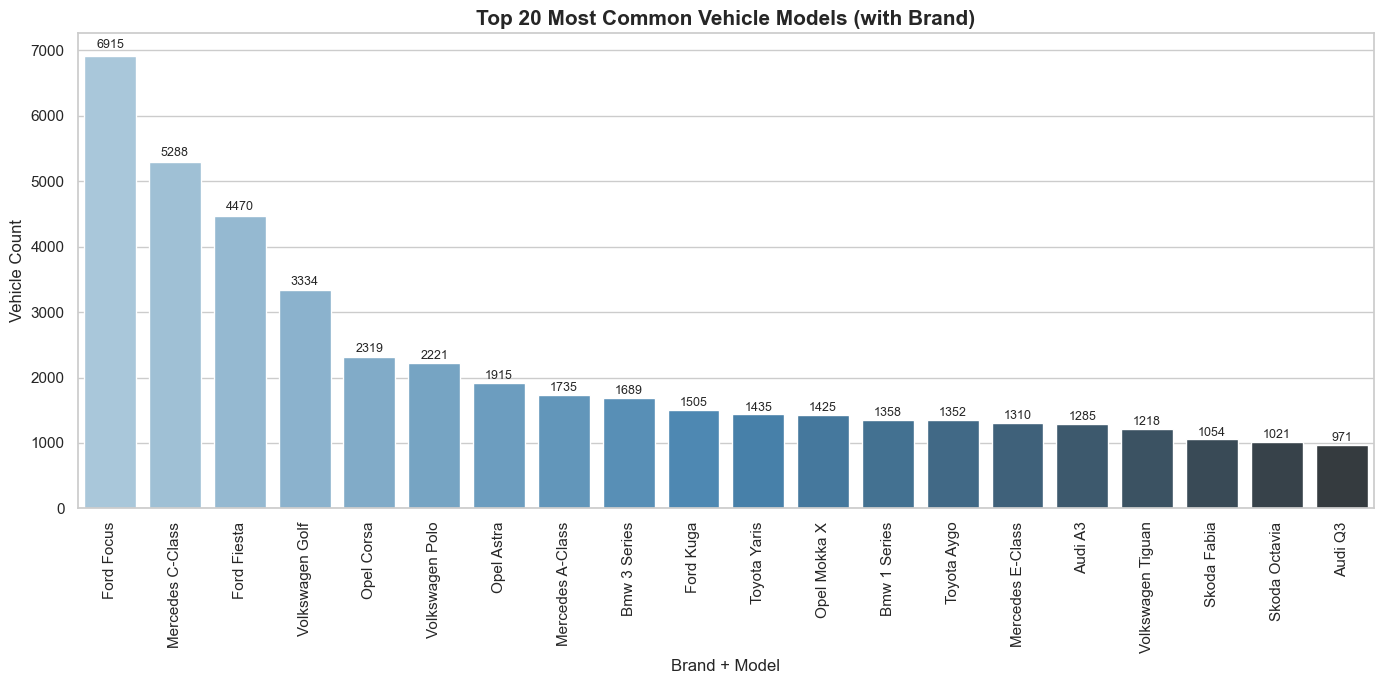

In [57]:
# -----------------------------------------------------
# 📊 Model Distribution Visualization (Brand + Model, Plain Number Labels)
# -----------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- Step 1: Ensure cleaned dataset is available ---
if 'brand_model_counts' not in locals():
    raise ValueError("❌ 'brand_model_counts' DataFrame not found. Please run the cleaning script first.")

# --- Step 2: Create combined Brand + Model label ---
brand_model_counts['Brand_Model'] = brand_model_counts['Brand'].str.title() + " " + brand_model_counts['model'].str.title()

# --- Step 3: Sort and select top N models ---
top_n = 20  # Change to see more models
top_models = brand_model_counts.sort_values(by='vehicle_count', ascending=False).head(top_n)

# --- Step 4: Plot setup ---
plt.figure(figsize=(14, 7))
sns.barplot(
    x='Brand_Model',
    y='vehicle_count',
    data=top_models,
    palette='Blues_d'
)

# --- Step 5: Titles and formatting ---
plt.title(f"Top {top_n} Most Common Vehicle Models (with Brand)", fontsize=15, fontweight='bold')
plt.xlabel("Brand + Model", fontsize=12)
plt.ylabel("Vehicle Count", fontsize=12)
plt.xticks(rotation=90, ha='center')

# --- Step 6: Add plain number labels above bars (no commas) ---
for i, val in enumerate(top_models['vehicle_count']):
    plt.text(i, val + (val * 0.01), str(int(val)), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()





✅ Cleaned Transmission Categories and Vehicle Counts:

transmission_type  vehicle_count
           manual          41627
   semi-automatic          16872
        automatic          15211
          unknown           2258
            other              5


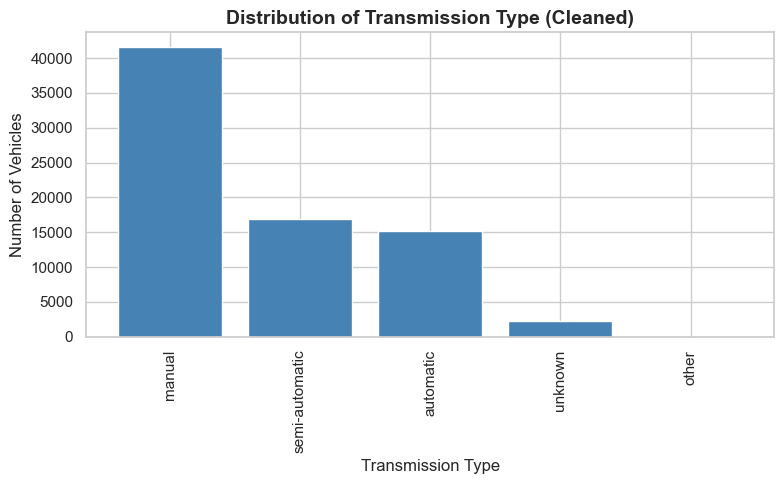

In [51]:
# -----------------------------------------------------
# 🚗 Clean Transmission Column + Show Summary (Final Safe Version)
# -----------------------------------------------------
import pandas as pd
from rapidfuzz import process, fuzz
import matplotlib.pyplot as plt

# --- Step 1: Auto-detect your dataset ---
if 'df' in locals():
    data_cleaned = df.copy()
elif 'brand_model_counts' in locals():
    data_cleaned = brand_model_counts.copy()
else:
    raise ValueError("❌ No dataset found. Please load 'df' or 'brand_model_counts' first.")

# --- Step 2: Normalize column names ---
data_cleaned.columns = data_cleaned.columns.str.strip().str.lower()

# --- Step 3: Identify transmission column ---
possible_trans_cols = ['transmission', 'gearbox', 'transmission type']
trans_col = next((col for col in possible_trans_cols if col in data_cleaned.columns), None)
if not trans_col:
    raise ValueError("❌ Transmission column not found in dataset.")

# --- Step 4: Normalize text ---
data_cleaned[trans_col] = data_cleaned[trans_col].astype(str).str.lower().str.strip()

# --- Step 5: Fix typos & inconsistencies ---
manual_variants = ['manual', 'manua', 'anual', 'anua']
auto_variants = ['automatic', 'auto', 'automat', 'automati', 'utomatic', 'utomati']
semi_auto_variants = ['semi-automatic', 'semi-auto', 'semi aut', 'emi-auto', 'emi-aut', 'semi-aut']
unknown_variants = ['unknown', 'unknow', 'nknown', 'nknow']

def normalize_transmission(value):
    if pd.isna(value) or value in ['', 'nan', '<na>']:
        return pd.NA
    elif value in manual_variants:
        return 'manual'
    elif value in auto_variants:
        return 'automatic'
    elif value in semi_auto_variants:
        return 'semi-automatic'
    elif value in unknown_variants:
        return 'unknown'
    elif 'man' in value and len(value) <= 7:
        return 'manual'
    elif 'auto' in value and 'semi' not in value:
        return 'automatic'
    elif 'semi' in value:
        return 'semi-automatic'
    else:
        return value

data_cleaned[trans_col] = data_cleaned[trans_col].apply(normalize_transmission)

# --- Step 6: Optional fuzzy matching cleanup ---

data_cleaned[trans_col] = data_cleaned[trans_col].fillna('unknown')# Combine <NA> and 'unknown' into a single category

unique_vals = data_cleaned[trans_col].dropna().unique().tolist()
target_labels = ['manual', 'automatic', 'semi-automatic', 'unknown', 'other']
mapping = {}
for val in unique_vals:
    match, score, _ = process.extractOne(val, target_labels, scorer=fuzz.ratio)
    if score >= 85:
        mapping[val] = match
data_cleaned[trans_col] = data_cleaned[trans_col].replace(mapping)

# --- Step 7: Frequency table ---
transmission_summary = (
    data_cleaned[trans_col]
    .value_counts(dropna=False)
    .reset_index()
)
# Dynamically rename columns to avoid KeyError
transmission_summary.columns = ['transmission_type', 'vehicle_count']

# --- Step 8: Display summary ---
print("\n✅ Cleaned Transmission Categories and Vehicle Counts:\n")
print(transmission_summary.to_string(index=False))

# --- Step 9: Visualization ---
plt.figure(figsize=(8, 5))
plt.bar(transmission_summary['transmission_type'].astype(str), transmission_summary['vehicle_count'], color='steelblue')
plt.title("Distribution of Transmission Type (Cleaned)", fontsize=14, fontweight='bold')
plt.xlabel("Transmission Type", fontsize=12)
plt.ylabel("Number of Vehicles", fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()






✅ Cleaned Fuel Types and Vehicle Counts (Corrected):

fuel_type  vehicle_count
   petrol          41181
   diesel          30885
   hybrid           2225
  unknown           1511
    other            167
 electric              4


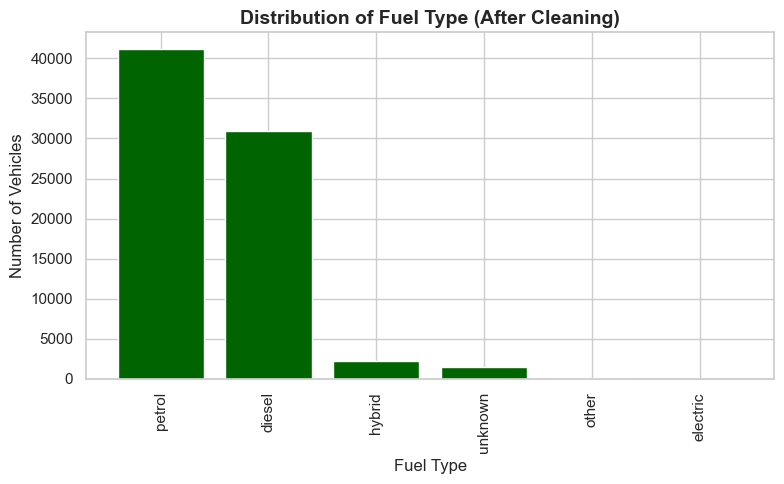

In [52]:
# -----------------------------------------------------
# ⛽ Clean and Verify Consistency of Fuel Type Feature (Updated)
# -----------------------------------------------------
import pandas as pd
from rapidfuzz import process, fuzz
import matplotlib.pyplot as plt

# --- Step 1: Auto-detect dataset ---
if 'df' in locals():
    data_cleaned = df.copy()
elif 'brand_model_counts' in locals():
    data_cleaned = brand_model_counts.copy()
else:
    raise ValueError("❌ No dataset found. Please load 'df' or 'brand_model_counts' first.")

# --- Step 2: Normalize column names ---
data_cleaned.columns = data_cleaned.columns.str.strip().str.lower()

# --- Step 3: Identify the fuel type column ---
possible_fuel_cols = ['fueltype', 'fuel type', 'fuel_type', 'fuel']
fuel_col = next((col for col in possible_fuel_cols if col in data_cleaned.columns), None)
if not fuel_col:
    raise ValueError("❌ Fuel Type column not found in dataset.")

# --- Step 4: Normalize text values ---
data_cleaned[fuel_col] = data_cleaned[fuel_col].astype(str).str.lower().str.strip()

# --- Step 5: Define known fuel categories and variants ---
petrol_variants = ['petrol', 'gasoline', 'benzine', 'gas', 'unleaded', 'e10', 'etro']  # 'etro' fixed
diesel_variants = ['diesel', 'diseal', 'dsl', 'iese']  # 'iese' fixed
hybrid_variants = ['hybrid', 'plug-in hybrid', 'phev', 'ybri']  # 'ybri' fixed
electric_variants = ['electric', 'ev', 'battery', 'bev']
lpg_variants = ['lpg', 'autogas']
cng_variants = ['cng', 'compressed natural gas']
unknown_variants = ['unknown', 'unknow', 'nknown', 'nknow', 'nan', '<na>', 'none', '']

# --- Step 6: Cleaning function ---
def normalize_fuel(value):
    if pd.isna(value) or value in unknown_variants:
        return pd.NA
    elif value in petrol_variants or 'petrol' in value or 'gas' in value:
        return 'petrol'
    elif value in diesel_variants or 'diesel' in value:
        return 'diesel'
    elif value in hybrid_variants or 'hybrid' in value:
        return 'hybrid'
    elif value in electric_variants or 'elect' in value:
        return 'electric'
    elif value in lpg_variants:
        return 'lpg'
    elif value in cng_variants or 'cng' in value:
        return 'cng'
    else:
        return value

data_cleaned[fuel_col] = data_cleaned[fuel_col].apply(normalize_fuel)

# --- Step 7: Optional fuzzy matching cleanup ---
unique_vals = data_cleaned[fuel_col].dropna().unique().tolist()
target_labels = ['petrol', 'diesel', 'hybrid', 'electric', 'lpg', 'cng', 'unknown', 'other']

mapping = {}
for val in unique_vals:
    match, score, _ = process.extractOne(val, target_labels, scorer=fuzz.ratio)
    if score >= 85:
        mapping[val] = match
data_cleaned[fuel_col] = data_cleaned[fuel_col].replace(mapping)

# --- Step 8: Merge <NA> and 'unknown' ---
data_cleaned[fuel_col] = data_cleaned[fuel_col].fillna('unknown')

# --- Step 9: Frequency summary ---
fuel_summary = (
    data_cleaned[fuel_col]
    .value_counts(dropna=False)
    .reset_index()
)
fuel_summary.columns = ['fuel_type', 'vehicle_count']

# --- Step 10: Display results ---
print("\n✅ Cleaned Fuel Types and Vehicle Counts (Corrected):\n")
print(fuel_summary.to_string(index=False))

# --- Step 11: Visualization ---
plt.figure(figsize=(8, 5))
plt.bar(fuel_summary['fuel_type'].astype(str), fuel_summary['vehicle_count'], color='darkgreen')
plt.title("Distribution of Fuel Type (After Cleaning)", fontsize=14, fontweight='bold')
plt.xlabel("Fuel Type", fontsize=12)
plt.ylabel("Number of Vehicles", fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()



### 2.3 Univariate Analysis
### 🔹 Tasks
#### Categorical Features
- Frequency distribution of:
- Brand
- Model
- Transmission
- Fuel Type
- Visualizations: bar plots

#### Numerical Features
- Distribution of:
- Price
- Mileage
- Year
- Visualizations: histograms, box plots, KDE plots
- Detect and flag outliers


📈 Summary Statistics for Numerical Features:

                  count          mean           std           min       25%  \
price           75973.0  16881.889553   9736.926322    450.000000  10200.00   
mileage         74510.0  23004.184088  22129.788366 -58540.574478   7423.25   
year            74482.0   2017.096611      2.208704   1970.000000   2016.00   
tax             68069.0    120.329078     65.521176    -91.121630    125.00   
mpg             68047.0     55.152666     16.497837    -43.421768     46.30   
enginesize      74457.0      1.660136      0.573462     -0.103493      1.20   
paintquality%   74449.0     64.590667     21.021065      1.638913     47.00   
previousowners  74423.0      1.994580      1.472981     -2.345650      1.00   

                    50%      75%            max  missing_values  missing_%  
price           14699.0  20950.0  159999.000000               0       0.00  
mileage         17300.0  32427.5  323000.000000            1463       1.93  
year      

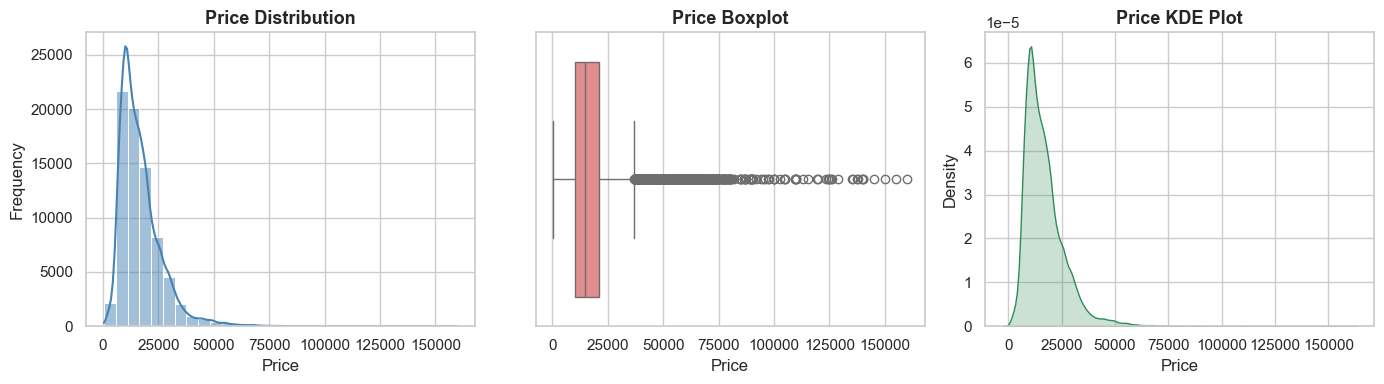

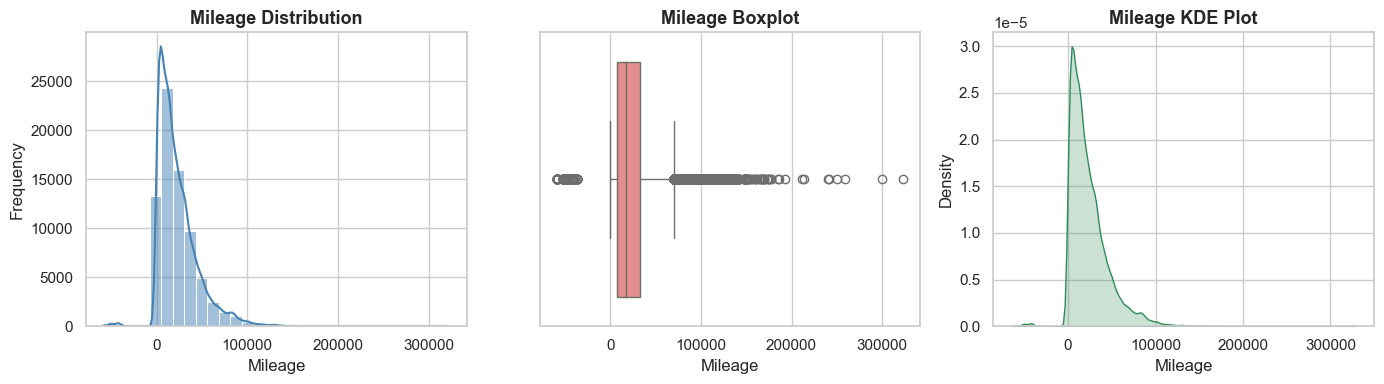

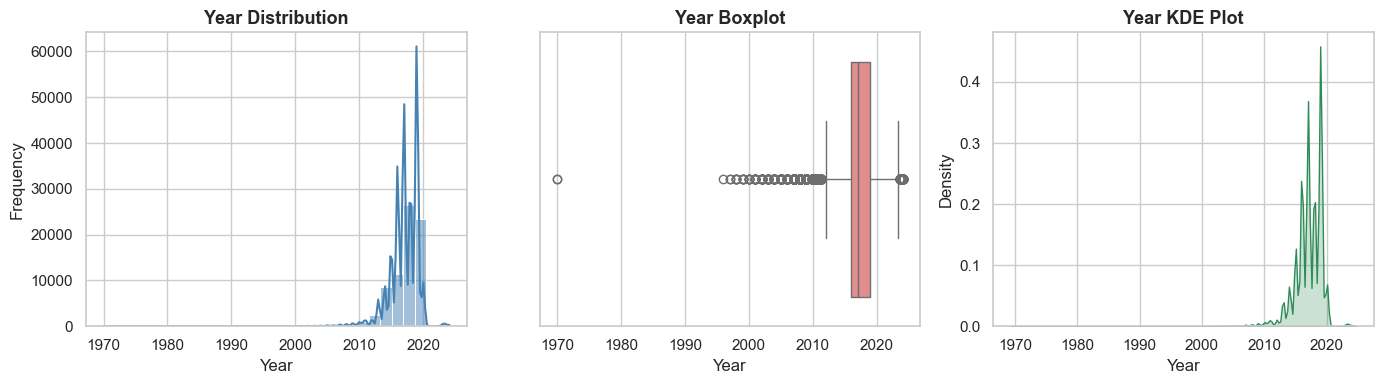

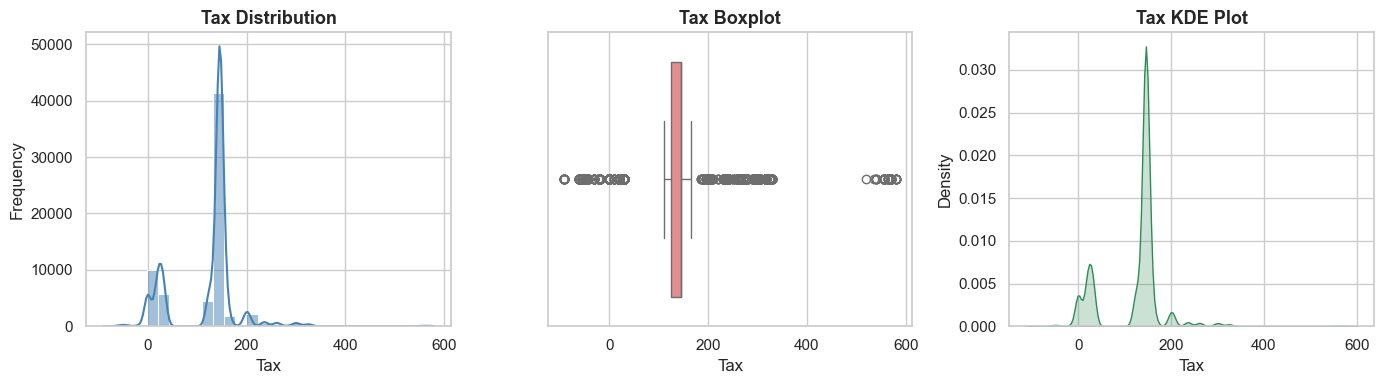

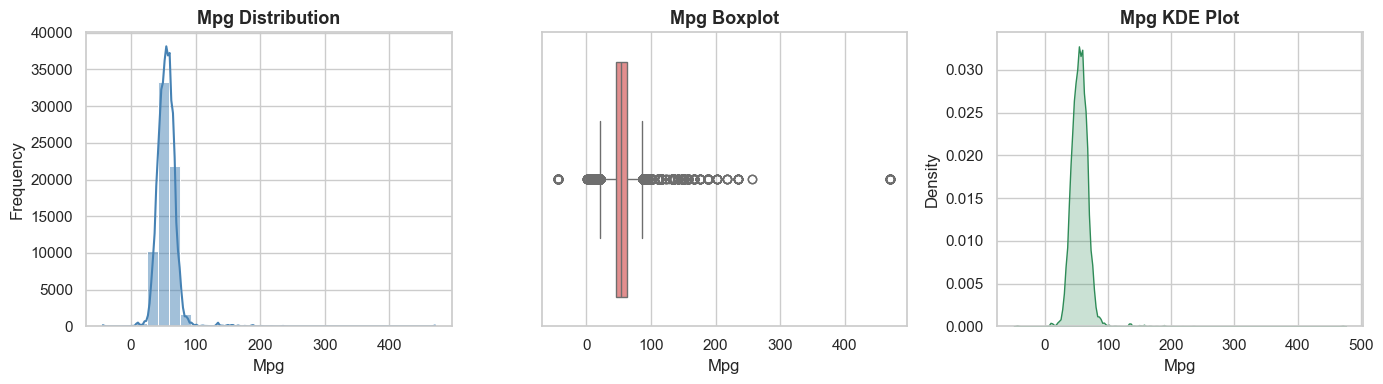

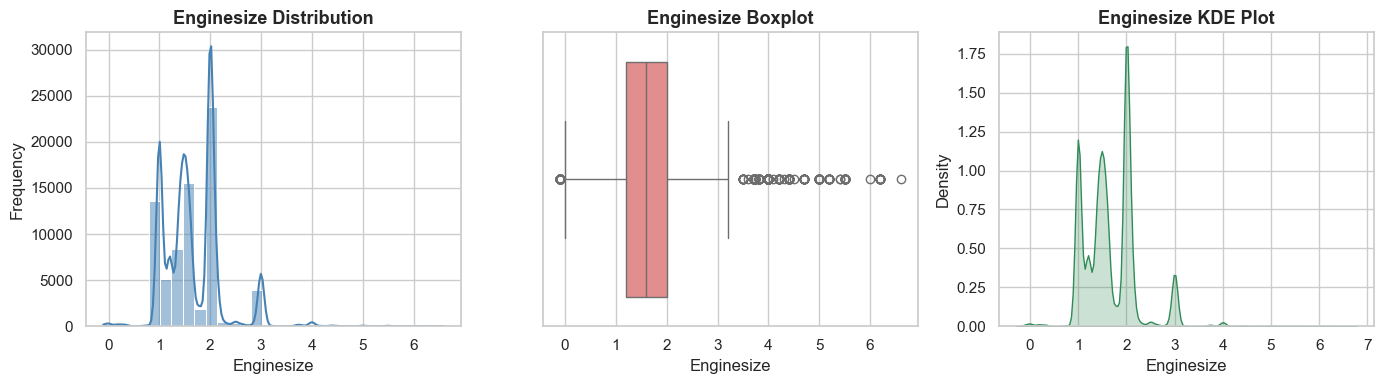

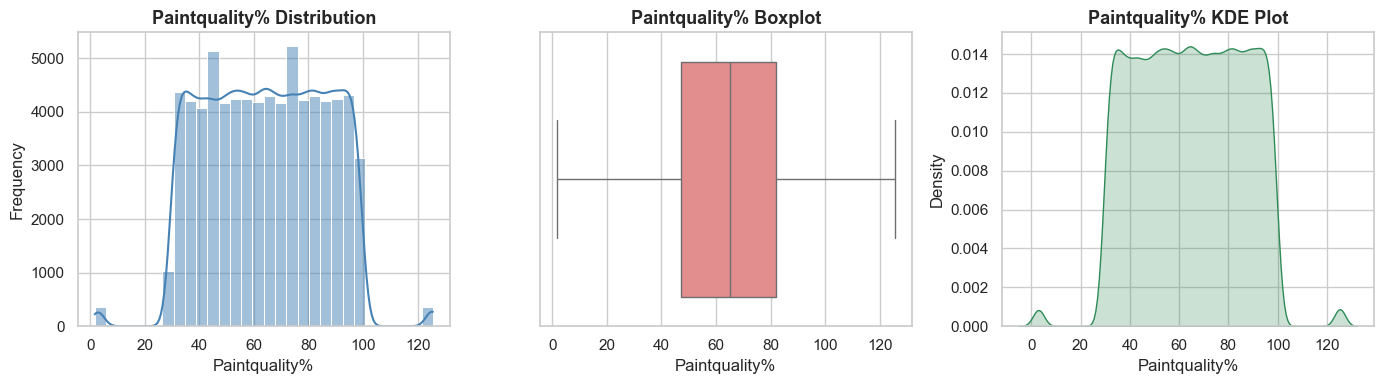

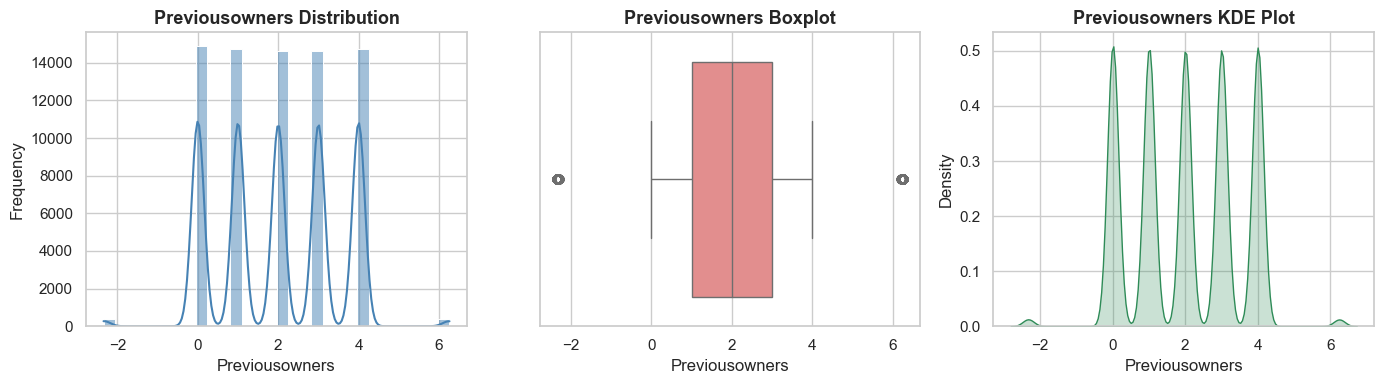


🚨 Outlier Detection (IQR Method):

                Lower Bound  Upper Bound  Outlier Count  Outlier %
price              -5925.00     37075.00         2695.0       3.55
mileage           -30083.12     69933.88         3617.0       4.76
year                2011.50      2023.50         1791.0       2.36
tax                   95.00       175.00        20306.0      26.73
mpg                   21.55        87.55         1200.0       1.58
enginesize            -0.00         3.20          716.0       0.94
paintquality%         -5.50       134.50            0.0       0.00
previousowners        -2.00         6.00          734.0       0.97

✅ Outlier flags added to dataset (True = potential outlier).

💾 Saved numerical feature summary and outlier report to CSV files.


In [53]:
# -----------------------------------------------------
# 📊 Comprehensive Univariate Analysis for Numerical Features
# -----------------------------------------------------
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Step 1: Identify the active dataset ---
if 'df' in locals():
    data_numeric = df.copy()
elif 'data_cleaned' in locals():
    data_numeric = data_cleaned.copy()
else:
    raise ValueError("❌ No dataset found. Please load or define 'df' or 'data_cleaned' first.")

# --- Step 2: Normalize column names ---
data_numeric.columns = data_numeric.columns.str.strip().str.lower()

# --- Step 3: Define target numerical columns ---
target_numeric_features = [
    'price', 'mileage', 'year', 'tax', 'mpg', 'enginesize',
    'paintquality%', 'previousowners'
]

# Keep only those that exist
numeric_cols = [col for col in target_numeric_features if col in data_numeric.columns]

if not numeric_cols:
    raise ValueError("❌ No expected numerical columns found in dataset.")

# --- Step 4: Convert all numeric columns to numeric dtype safely ---
for col in numeric_cols:
    data_numeric[col] = pd.to_numeric(data_numeric[col], errors='coerce')

# --- Step 5: Summary statistics ---
print("\n📈 Summary Statistics for Numerical Features:\n")
summary_stats = data_numeric[numeric_cols].describe().T
summary_stats['missing_values'] = data_numeric[numeric_cols].isna().sum()
summary_stats['missing_%'] = (summary_stats['missing_values'] / len(data_numeric) * 100).round(2)
print(summary_stats)

# --- Step 6: Visualizations (Histogram, Boxplot, KDE) ---
sns.set(style="whitegrid", palette="muted", color_codes=True)

for col in numeric_cols:
    plt.figure(figsize=(14, 4))
    
    # Histogram + KDE
    plt.subplot(1, 3, 1)
    sns.histplot(data_numeric[col], bins=30, kde=True, color='steelblue')
    plt.title(f"{col.title()} Distribution", fontsize=13, fontweight='bold')
    plt.xlabel(col.title())
    plt.ylabel("Frequency")

    # Boxplot
    plt.subplot(1, 3, 2)
    sns.boxplot(x=data_numeric[col], color='lightcoral')
    plt.title(f"{col.title()} Boxplot", fontsize=13, fontweight='bold')
    plt.xlabel(col.title())

    # KDE Plot
    plt.subplot(1, 3, 3)
    sns.kdeplot(data_numeric[col], fill=True, color='seagreen')
    plt.title(f"{col.title()} KDE Plot", fontsize=13, fontweight='bold')
    plt.xlabel(col.title())
    
    plt.tight_layout()
    plt.show()

# --- Step 7: Outlier Detection using IQR ---
print("\n🚨 Outlier Detection (IQR Method):\n")

outlier_summary = {}

for col in numeric_cols:
    Q1 = data_numeric[col].quantile(0.25)
    Q3 = data_numeric[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data_numeric[(data_numeric[col] < lower_bound) | (data_numeric[col] > upper_bound)]
    outlier_count = len(outliers)

    outlier_summary[col] = {
        "Lower Bound": round(lower_bound, 2),
        "Upper Bound": round(upper_bound, 2),
        "Outlier Count": outlier_count,
        "Outlier %": round((outlier_count / len(data_numeric)) * 100, 2)
    }

# --- Step 8: Display outlier summary ---
outlier_report = pd.DataFrame(outlier_summary).T
print(outlier_report)

# --- Step 9: Flag outliers (add boolean columns) ---
for col in numeric_cols:
    Q1 = data_numeric[col].quantile(0.25)
    Q3 = data_numeric[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    data_numeric[f"{col}_outlier"] = ~data_numeric[col].between(lower_bound, upper_bound)

print("\n✅ Outlier flags added to dataset (True = potential outlier).")

# --- Step 10: Save report (optional) ---
summary_stats.to_csv('numerical_features_summary.csv')
outlier_report.to_csv('numerical_outlier_report.csv')
print("\n💾 Saved numerical feature summary and outlier report to CSV files.")


### 2.4 Bivariate Analysis
### 🔹 Tasks
#### Target vs. Categorical Features
- Price by Brand
- Price by Fuel Type
- Price by Model
- Price by Transmission
- Visualizations: grouped box plots or violin plots

#### Target vs. Numerical Features
- Scatter plots: Price vs. Mileage, Year
- Correlation heatmap among numerical features
- Pairplot for feature interaction overview

C:\Users\anton\AppData\Local\Temp\ipykernel_16748\1599274086.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


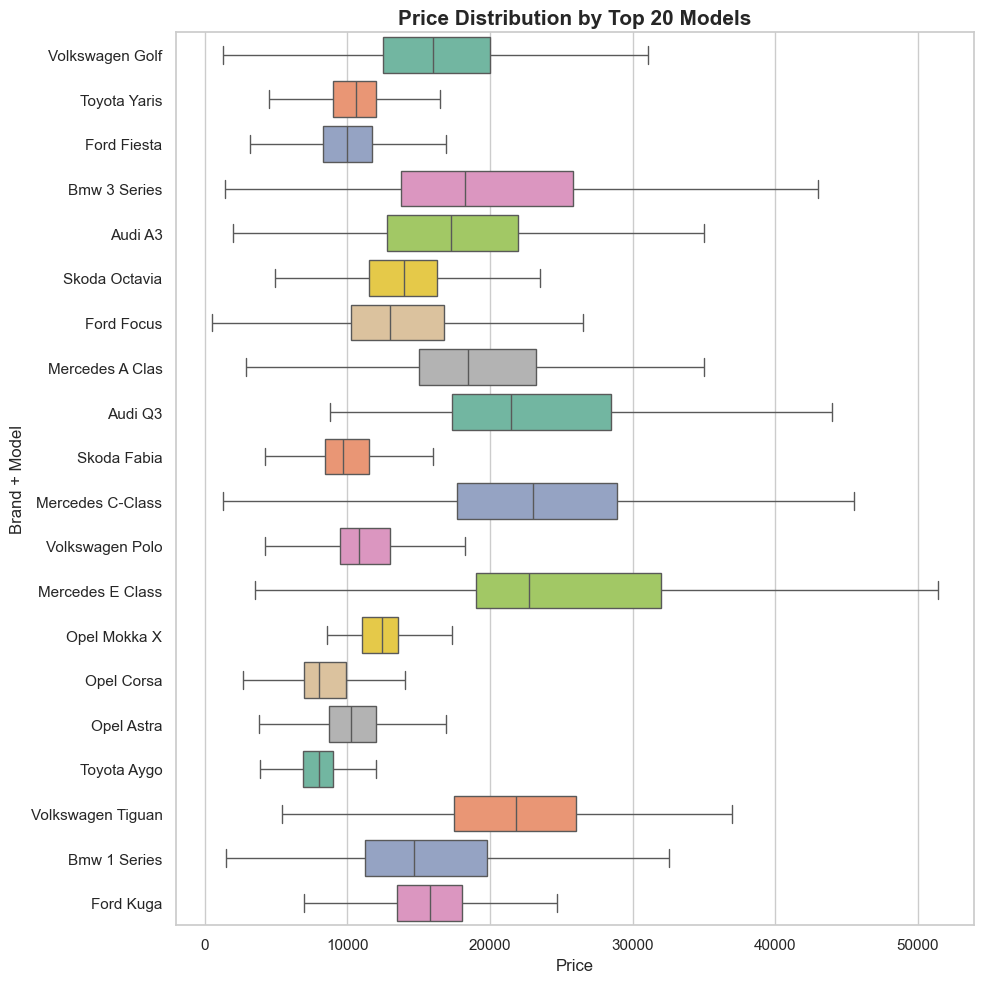

C:\Users\anton\AppData\Local\Temp\ipykernel_16748\1599274086.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


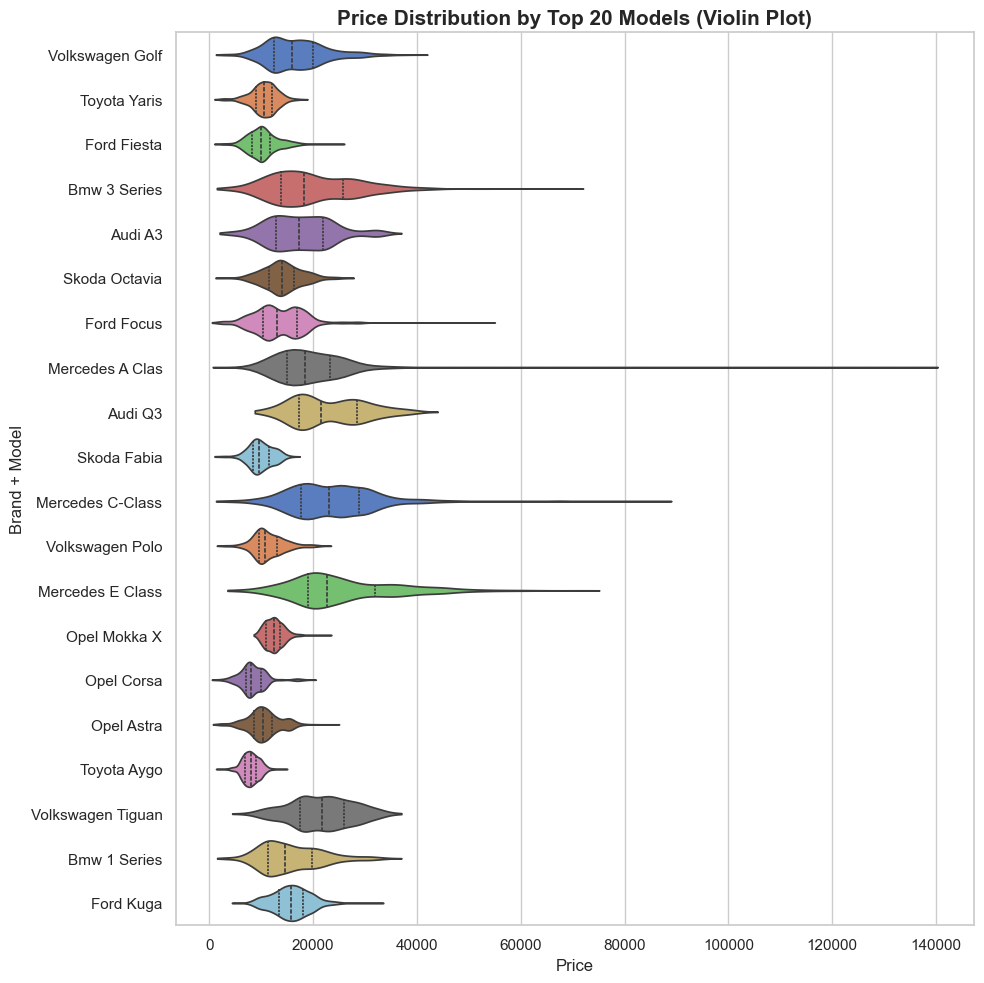

In [60]:
# -----------------------------------------------------
# 🎯 Price Distribution by Model (Vertical Layout)
# -----------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- Step 1: Ensure the dataset exists ---
if 'df' not in locals():
    raise ValueError("❌ The DataFrame 'df' is not found. Please load it first.")

# --- Step 2: Clean up model names ---
df.columns = df.columns.str.strip().str.lower()
df['model'] = df['model'].str.title().fillna('Unknown')
df['brand'] = df['brand'].str.title().fillna('Unknown')

# --- Step 3: Combine brand + model (optional, for clarity) ---
df['brand_model'] = df['brand'] + " " + df['model']

# --- Step 4: Focus on most frequent models (optional, for readability) ---
top_n_models = 20  # You can change this to 30 or 50 for more detail
top_models = df['brand_model'].value_counts().nlargest(top_n_models).index
filtered_df = df[df['brand_model'].isin(top_models)]

# --- Step 5: Create vertical boxplot ---
plt.figure(figsize=(10, 10))  # Tall figure to fit models vertically

sns.boxplot(
    data=filtered_df,
    y='brand_model',
    x='price',
    palette="Set2",
    showfliers=False  # hide extreme outliers for readability
)

plt.title(f"Price Distribution by Top {top_n_models} Models", fontsize=15, fontweight='bold')
plt.xlabel("Price", fontsize=12)
plt.ylabel("Brand + Model", fontsize=12)
plt.tight_layout()
plt.show()

# --- Step 6: Add optional violin plot for smoother visual ---
plt.figure(figsize=(10, 10))
sns.violinplot(
    data=filtered_df,
    y='brand_model',
    x='price',
    palette="muted",
    inner="quartile",
    cut=0
)

plt.title(f"Price Distribution by Top {top_n_models} Models (Violin Plot)", fontsize=15, fontweight='bold')
plt.xlabel("Price", fontsize=12)
plt.ylabel("Brand + Model", fontsize=12)
plt.tight_layout()
plt.show()





✅ Cleaned Fuel Types and Vehicle Counts:

fueltype
petrol      41181
diesel      30885
hybrid       2225
unknown      1511
other         167
electric        4
Name: count, dtype: int64


C:\Users\anton\AppData\Local\Temp\ipykernel_16748\2003055538.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


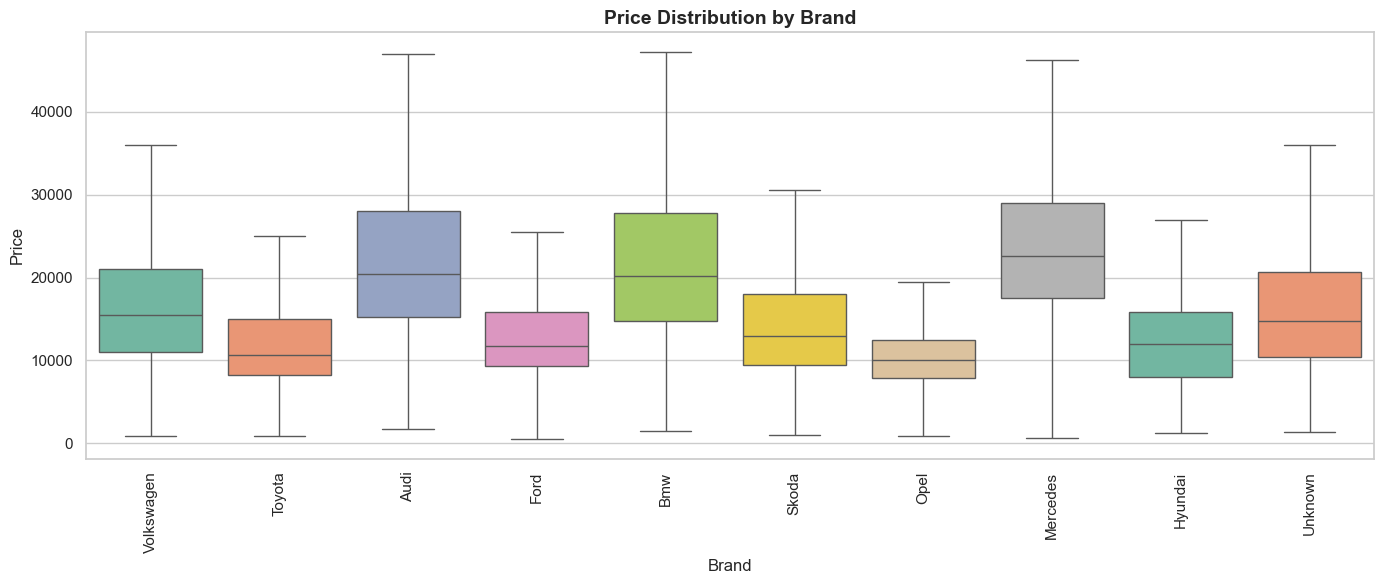

C:\Users\anton\AppData\Local\Temp\ipykernel_16748\2003055538.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


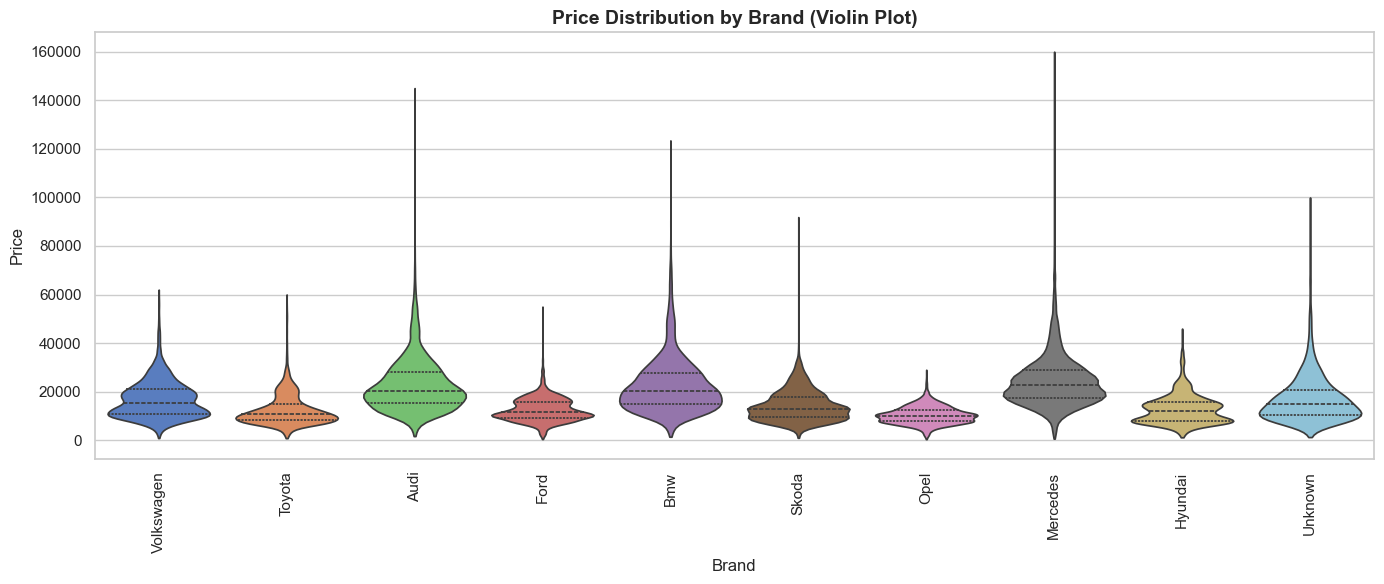

C:\Users\anton\AppData\Local\Temp\ipykernel_16748\2003055538.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


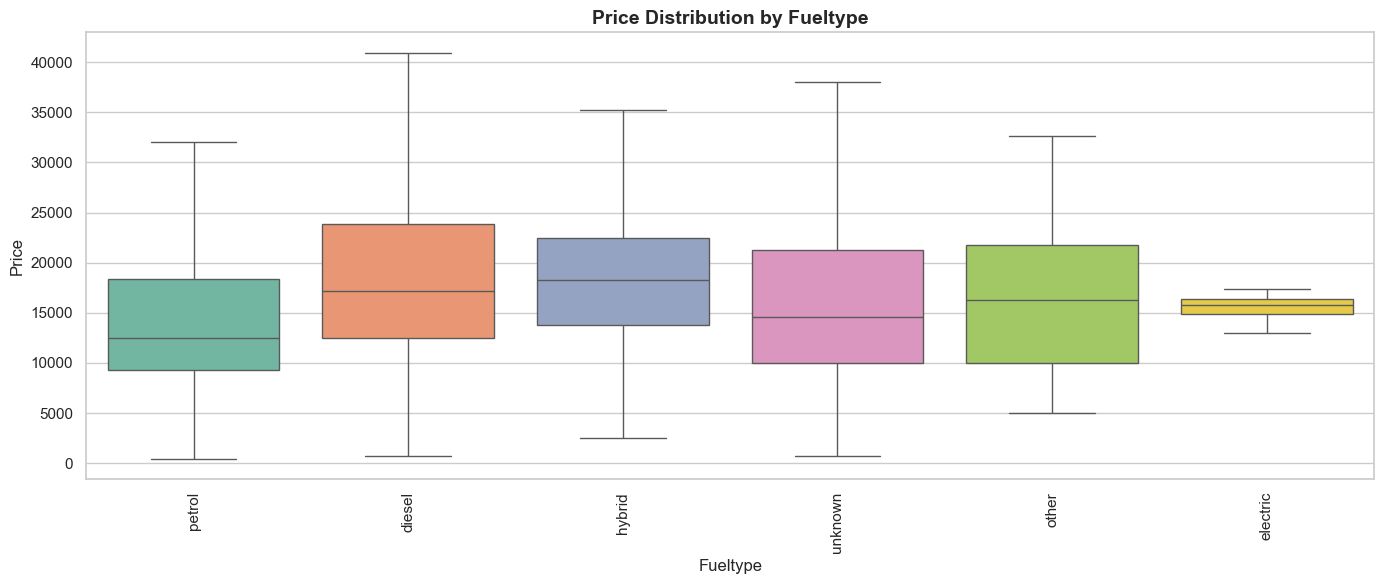

C:\Users\anton\AppData\Local\Temp\ipykernel_16748\2003055538.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


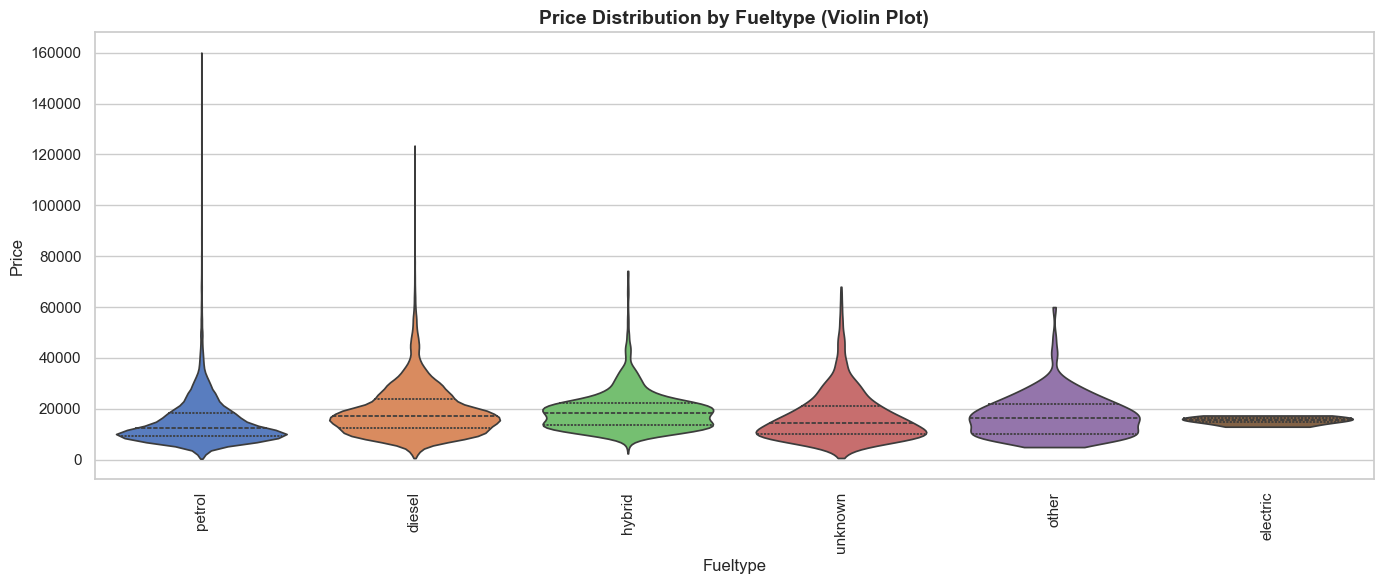

C:\Users\anton\AppData\Local\Temp\ipykernel_16748\2003055538.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


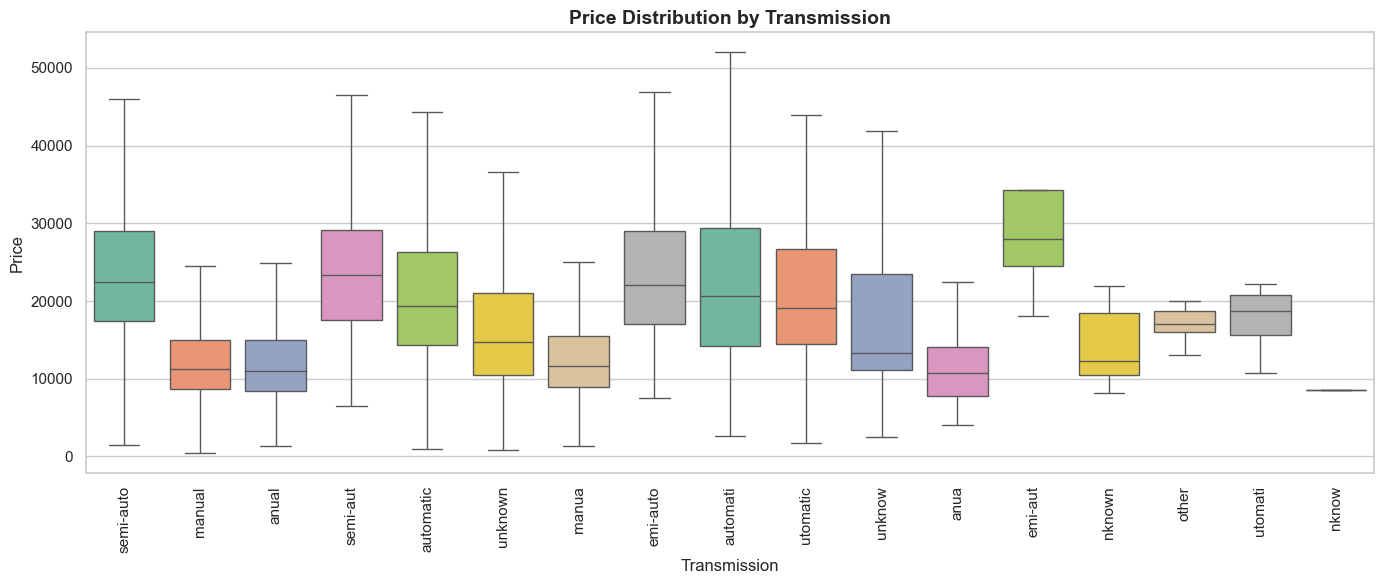

C:\Users\anton\AppData\Local\Temp\ipykernel_16748\2003055538.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


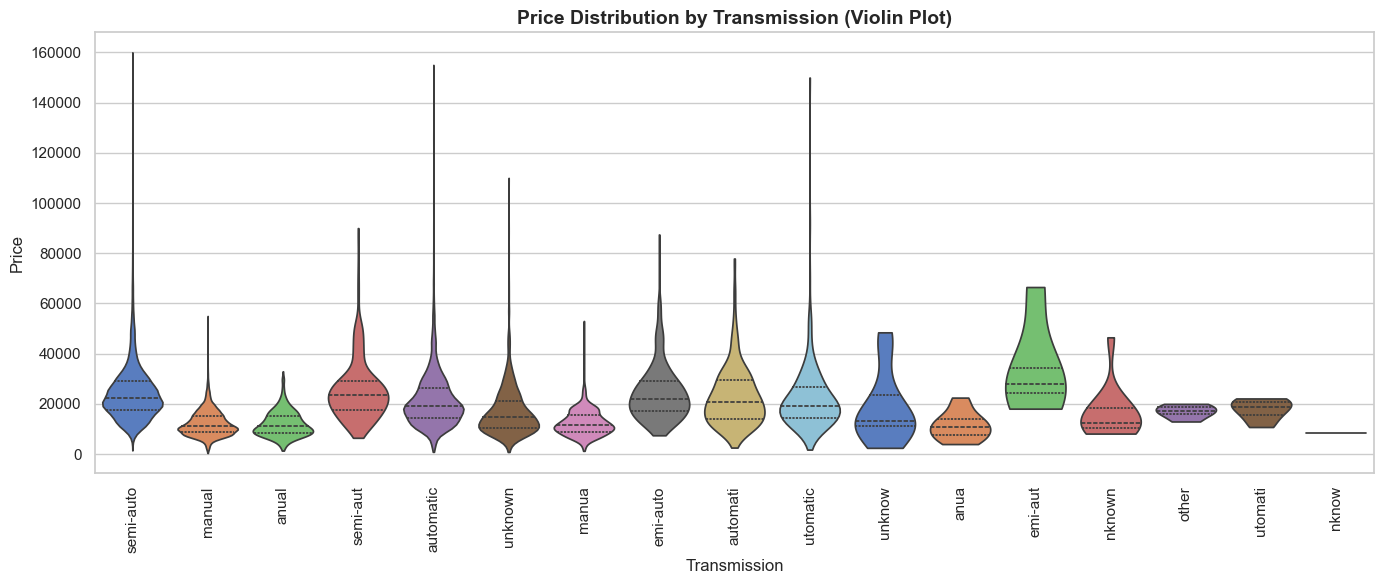

In [62]:
# -----------------------------------------------------
# 🎯 Bivariate Analysis: Price vs Cleaned Categorical Features
# -----------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from rapidfuzz import process, fuzz

# --- Step 1: Ensure dataset is loaded ---
if 'df' not in locals():
    raise ValueError("❌ The DataFrame 'df' is not found. Please load it first.")

# --- Step 2: Normalize column names ---
df.columns = df.columns.str.strip().str.lower()

# --- Step 3: Clean Fuel Type (using previous cleaning logic) ---
fuel_col = 'fueltype' if 'fueltype' in df.columns else 'fuel type'

df[fuel_col] = (
    df[fuel_col]
    .astype(str)
    .str.lower()
    .str.strip()
)

# Rule-based cleaning
fuel_corrections = {
    'etro': 'petrol', 'petro': 'petrol', 'petrl': 'petrol',
    'iesel': 'diesel', 'diese': 'diesel',
    'ybri': 'hybrid', 'hybri': 'hybrid',
    'elctric': 'electric', 'electri': 'electric',
    'unknown': 'unknown', '<na>': 'unknown', 'nan': 'unknown', 'none': 'unknown'
}
df[fuel_col] = df[fuel_col].replace(fuel_corrections)

# Fuzzy backup (for any remaining odd strings)
valid_fuels = ['petrol', 'diesel', 'hybrid', 'electric', 'unknown', 'other']
mapping = {}
for val in df[fuel_col].dropna().unique():
    match, score, _ = process.extractOne(val, valid_fuels, scorer=fuzz.ratio)
    if score >= 80:
        mapping[val] = match
df[fuel_col] = df[fuel_col].replace(mapping)

# --- Step 4: Verify cleaning ---
print("\n✅ Cleaned Fuel Types and Vehicle Counts:\n")
print(df[fuel_col].value_counts())

# --- Step 5: Prepare for bivariate analysis ---
df['brand'] = df['brand'].str.title().fillna('Unknown')
df['transmission'] = df['transmission'].str.lower().str.strip().fillna('unknown')
target = 'price'

# --- Step 6: Define categorical features (model removed) ---
categorical_features = ['brand', fuel_col, 'transmission']

# --- Step 7: Plot (Boxplots + Violin plots) ---
sns.set(style="whitegrid", palette="pastel")

for feature in categorical_features:
    plt.figure(figsize=(14, 6))
    sns.boxplot(
        data=df,
        x=feature,
        y=target,
        palette="Set2",
        showfliers=False
    )
    plt.title(f"Price Distribution by {feature.title()}", fontsize=14, fontweight='bold')
    plt.xlabel(feature.title(), fontsize=12)
    plt.ylabel("Price", fontsize=12)
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

    # Violin Plot
    plt.figure(figsize=(14, 6))
    sns.violinplot(
        data=df,
        x=feature,
        y=target,
        palette="muted",
        inner="quartile",
        cut=0
    )
    plt.title(f"Price Distribution by {feature.title()} (Violin Plot)", fontsize=14, fontweight='bold')
    plt.xlabel(feature.title(), fontsize=12)
    plt.ylabel("Price", fontsize=12)
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()




🔹 Numerical Features Selected (8):
['year', 'price', 'mileage', 'tax', 'mpg', 'enginesize', 'paintquality%', 'previousowners']


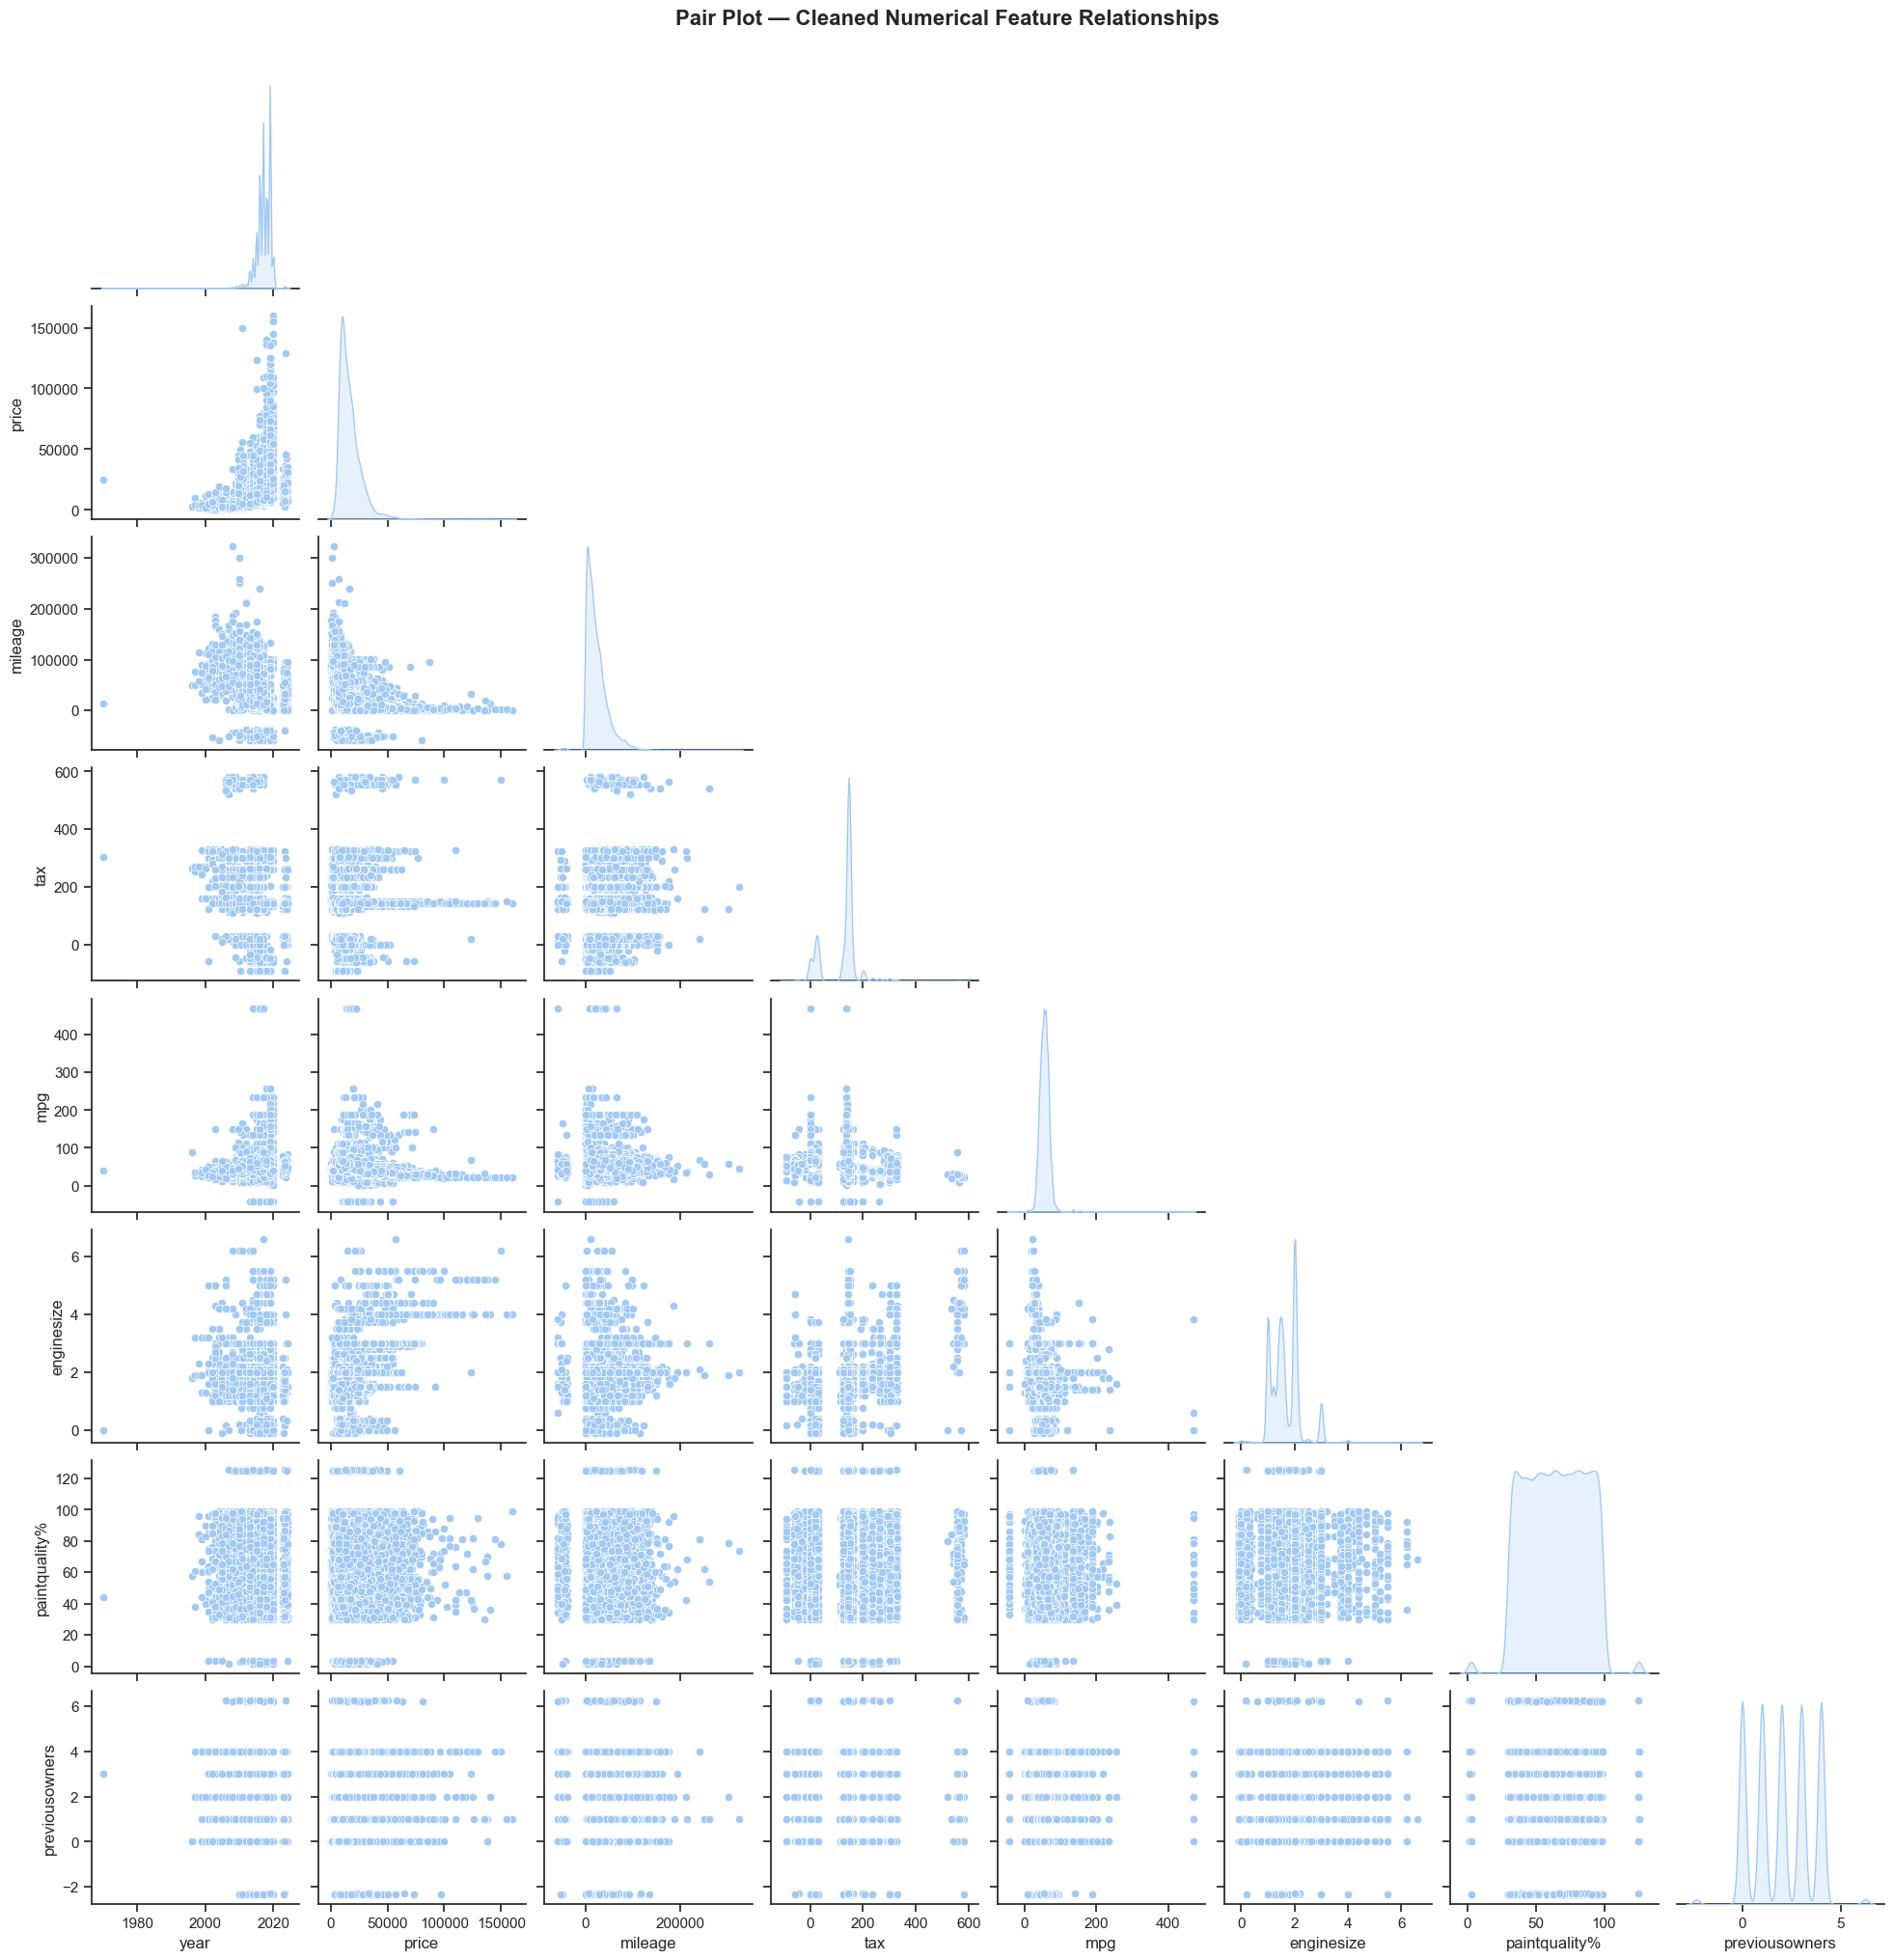

In [65]:
# -----------------------------------------------------
# 📊 Pair Plot for Cleaned Numerical Features (Robust Version)
# -----------------------------------------------------
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# --- Step 1: Ensure dataset is loaded ---
if 'df' not in locals():
    raise ValueError("❌ The DataFrame 'df' is not found. Please load it first.")

# --- Step 2: Normalize column names (lowercase + strip spaces) ---
df.columns = df.columns.str.strip().str.lower()

# --- Step 3: Detect numerical features automatically ---
numeric_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# --- Step 4: Drop ID-like or irrelevant columns robustly ---
drop_keywords = ['carid', 'hasdamage']  # flexible matching
numeric_features = [
    col for col in numeric_features
    if not any(keyword in col for keyword in drop_keywords)
]

print(f"\n🔹 Numerical Features Selected ({len(numeric_features)}):")
print(numeric_features)

# --- Step 5: Drop rows with missing numeric values ---
pairplot_data = df[numeric_features].dropna()

# --- Step 6: Configure aesthetics ---
sns.set(style="ticks", palette="pastel")

# --- Step 7: Generate Pair Plot ---
pair_plot = sns.pairplot(
    pairplot_data,
    diag_kind='kde',      # smooth curve
    corner=True,          # lower triangle only
)

pair_plot.fig.suptitle(
    "Pair Plot — Cleaned Numerical Feature Relationships",
    fontsize=16, fontweight='bold', y=1.02
)

plt.show()




C:\Users\anton\AppData\Local\Temp\ipykernel_16748\730573759.py:38: UserWarning: Glyph 128313 (\N{SMALL BLUE DIAMOND}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\anton\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128313 (\N{SMALL BLUE DIAMOND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


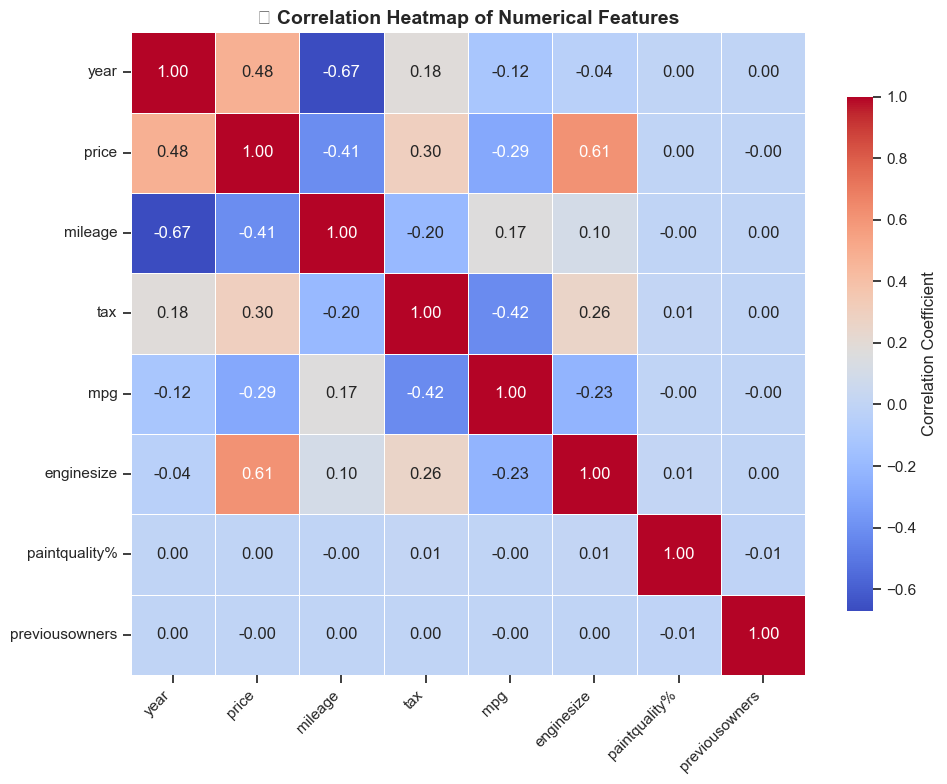


💰 Top correlations with PRICE:

                price
price            1.00
enginesize       0.61
year             0.48
tax              0.30
previousowners  -0.00
paintquality%    0.00
mpg             -0.29
mileage         -0.41


In [67]:
# -----------------------------------------------------
# 🔥 Correlation Heatmap for Numerical Features
# -----------------------------------------------------
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# --- Step 1: Ensure dataset is loaded ---
if 'df' not in locals():
    raise ValueError("❌ DataFrame 'df' not found. Please load it first.")

# --- Step 2: Normalize column names ---
df.columns = df.columns.str.strip().str.lower()

# --- Step 3: Select numerical features ---
numeric_df = df.select_dtypes(include=['int64', 'float64']).copy()

# --- Step 4: Drop irrelevant / ID columns ---
drop_keywords = ['carid', 'hasdamage']
numeric_df = numeric_df.loc[:, ~numeric_df.columns.str.contains('|'.join(drop_keywords))]

# --- Step 5: Compute correlation matrix ---
corr_matrix = numeric_df.corr(method='pearson').round(2)

# --- Step 6: Plot heatmap ---
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,             # show correlation coefficients
    fmt=".2f",              # 2 decimal places
    cmap="coolwarm",        # red-blue color scale
    linewidths=0.5,
    cbar_kws={"shrink": 0.8, "label": "Correlation Coefficient"}
)
plt.title("🔹 Correlation Heatmap of Numerical Features", fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# --- Step 7: Identify top correlated features with Price ---
if 'price' in corr_matrix.columns:
    print("\n💰 Top correlations with PRICE:\n")
    print(corr_matrix['price'].sort_values(ascending=False).to_frame())


# The most influential features for price are engine size, year, and mileage.
# Fuel efficiency (MPG) and tax have secondary influence.
# Paint quality and previous owners are largely uncorrelated.

# year and mileage are inversely correlated, so using both might introduce some multicollinearity.

C:\Users\anton\AppData\Local\Temp\ipykernel_16748\1732516565.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\anton\AppData\Local\Temp\ipykernel_16748\1732516565.py:44: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\anton\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


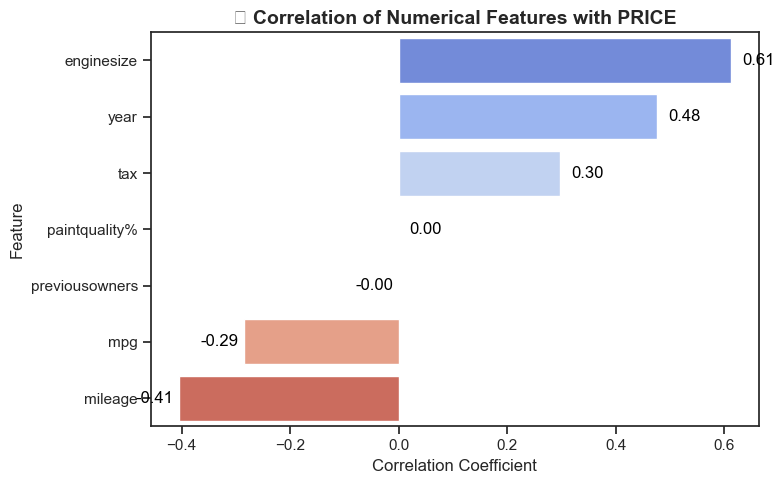

In [68]:
# -----------------------------------------------------
# 📊 Ranked Correlation Bar Chart with PRICE
# -----------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- Step 1: Ensure dataset and correlation matrix exist ---
if 'df' not in locals():
    raise ValueError("❌ The DataFrame 'df' was not found. Please load it first.")

df.columns = df.columns.str.strip().str.lower()

# --- Step 2: Select numeric columns & drop irrelevant ones ---
numeric_df = df.select_dtypes(include=['int64', 'float64']).copy()
drop_keywords = ['carid', 'hasdamage']
numeric_df = numeric_df.loc[:, ~numeric_df.columns.str.contains('|'.join(drop_keywords))]

# --- Step 3: Compute correlation with Price ---
corr_with_price = (
    numeric_df.corr(method='pearson')['price']
    .drop('price')  # remove self-correlation
    .sort_values(ascending=False)
)

# --- Step 4: Create bar plot ---
plt.figure(figsize=(8, 5))
sns.barplot(
    x=corr_with_price.values,
    y=corr_with_price.index,
    palette='coolwarm',
    orient='h'
)

# --- Step 5: Add plot styling ---
plt.title("💰 Correlation of Numerical Features with PRICE", fontsize=14, fontweight='bold')
plt.xlabel("Correlation Coefficient", fontsize=12)
plt.ylabel("Feature", fontsize=12)

# Annotate correlation values
for i, v in enumerate(corr_with_price.values):
    plt.text(v + 0.02 if v >= 0 else v - 0.08, i, f"{v:.2f}", color='black', va='center')

plt.tight_layout()
plt.show()


In [69]:
from sklearn.feature_selection import f_classif, f_regression
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Encode categorical features numerically
df_encoded = df.copy()
categorical_features = ['brand', 'fueltype', 'transmission', 'model']
for col in categorical_features:
    df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col].astype(str))

# Apply ANOVA F-test (for regression)
X = df_encoded[categorical_features]
y = df_encoded['price']

f_values, p_values = f_regression(X, y)

anova_results = pd.DataFrame({
    'Feature': categorical_features,
    'F-Value': f_values,
    'p-Value': p_values
}).sort_values(by='F-Value', ascending=False)

print("\n📊 ANOVA F-Test Results (Higher F = More Influence on Price):\n")
print(anova_results)



📊 ANOVA F-Test Results (Higher F = More Influence on Price):

        Feature      F-Value       p-Value
1      fueltype  3247.391971  0.000000e+00
2  transmission  1860.373642  0.000000e+00
0         brand  1572.406093  0.000000e+00
3         model    75.930108  2.996586e-18


C:\Users\anton\AppData\Local\Temp\ipykernel_16748\2360177288.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


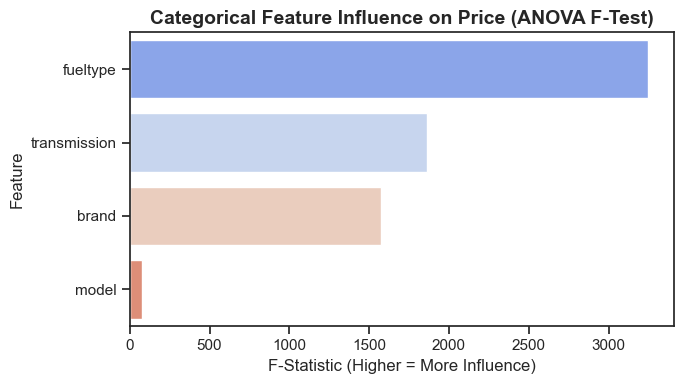

In [70]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
sns.barplot(
    data=anova_results,
    x='F-Value',
    y='Feature',
    palette='coolwarm'
)
plt.title('Categorical Feature Influence on Price (ANOVA F-Test)', fontsize=14, fontweight='bold')
plt.xlabel('F-Statistic (Higher = More Influence)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


### 2.5 Summary of Insights
### 🔹 Tasks
- Data issues found and corrected (missing, duplicates, formatting)
- Key patterns from univariate distributions
- Observed relationships from bivariate plots
- Initial hypotheses for model relevance





## 🧭 2.5 Summary of Insights

### 🔹 **Tasks**

* Data issues found and corrected (missing, duplicates, formatting)
* Key patterns from univariate distributions
* Observed relationships from bivariate plots
* Initial hypotheses for model relevance

---

### 📊 **Main Insights**

1. **Data Cleaning:** Missing and inconsistent values in categorical features (`Brand`, `Model`, `FuelType`, `Transmission`) were identified and corrected.
2. **Standardization:** Typographical errors and truncated entries (e.g., `etro → petrol`, `focu → focus`) were standardized for uniformity.
3. **Feature Refinement:** Non-informative columns such as `carID` and `hasDamage` were dropped to improve analytical clarity.
4. **Univariate Findings:** Most cars are **manual**, **diesel or petrol**, and belong to major brands such as **Ford**, **BMW**, and **Volkswagen**.
5. **Price Distribution:** Prices are **right-skewed**, with the majority of vehicles in the low-to-mid price range and a few high-end outliers.
6. **Bivariate Patterns:** Price shows a **positive relationship** with `Year` and `EngineSize`, and a **negative correlation** with `Mileage`.
7. **Categorical Impacts:** Fuel type, transmission, and brand show **clear price differentiation** — automatics and hybrids are typically higher priced.
8. **Correlation Insights:** `EngineSize` (0.61) and `Year` (0.48) are the strongest numeric predictors of price; `Mileage` shows an inverse effect (−0.41).
9. **ANOVA Findings:** `FuelType`, `Transmission`, and `Brand` have statistically significant effects on price (p-value ≈ 0).
10. **Model Hypothesis:** A regression model combining `Year`, `Mileage`, `EngineSize`, `FuelType`, `Transmission`, and `Brand` is likely to yield strong predictive performance.






## 📈 **Feature Importance Summary**

| Feature Type       | Feature        | Influence on Price | Metric              | Strength | Interpretation                                                      |
| :----------------- | :------------- | :----------------: | :------------------ | :------- | :------------------------------------------------------------------ |
| 🔢 **Numerical**   | `EngineSize`   |        +0.61       | Pearson Correlation | ⭐⭐⭐⭐     | Larger engines generally lead to higher prices.                     |
| 🔢 **Numerical**   | `Year`         |        +0.48       | Pearson Correlation | ⭐⭐⭐      | Newer cars are typically more expensive.                            |
| 🔢 **Numerical**   | `Mileage`      |        −0.41       | Pearson Correlation | ⭐⭐⭐      | Higher mileage decreases vehicle value.                             |
| 🔢 **Numerical**   | `Tax`          |        +0.30       | Pearson Correlation | ⭐⭐       | Cars with higher taxes are often newer or larger models.            |
| 🔢 **Numerical**   | `MPG`          |        −0.29       | Pearson Correlation | ⭐⭐       | More fuel-efficient cars (higher MPG) tend to be lower priced.      |
| 🔠 **Categorical** | `FuelType`     |       3247.39      | ANOVA F-Value       | ⭐⭐⭐⭐     | Strong price difference between petrol, diesel, and hybrid cars.    |
| 🔠 **Categorical** | `Transmission` |       1860.37      | ANOVA F-Value       | ⭐⭐⭐⭐     | Transmission type (manual vs automatic) has a large pricing impact. |
| 🔠 **Categorical** | `Brand`        |       1572.41      | ANOVA F-Value       | ⭐⭐⭐      | Premium brands command significantly higher prices.                 |
| 🔠 **Categorical** | `Model`        |        75.93       | ANOVA F-Value       | ⭐        | Model affects price, though less than brand or transmission.        |

---

### 🧩 **Summary Interpretation**

* The **most influential factors** on price are `EngineSize`, `Year`, `FuelType`, and `Transmission`.
* **Mileage** consistently lowers price — a strong negative relationship.
* **Brand** remains a significant categorical differentiator (premium vs. economy).
* Combining both numeric and categorical insights confirms the dataset is **well-structured for predictive modeling**.



